In [ ]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================
!pip install gradio torch scikit-learn pandas numpy matplotlib seaborn tqdm shap -q

In [ ]:
# ============================================================
# CELL 2: All imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_recall_curve, roc_auc_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings, copy, time, random, os, struct, io, collections
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
# ============================================================
# CELL 3: Load & basic EDA
# ============================================================
df_raw = pd.read_csv("/content/astronaut_disorientation_dataset.csv")
print("Shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nClass balance:\n", df_raw["Error_Label"].value_counts())

# ── Session-as-Astronaut mapping (each session = one woman astronaut) ──
print("\nUnique sessions (each = one woman astronaut):", df_raw["Session_ID"].nunique())
print("Sessions:", df_raw["Session_ID"].unique().tolist())

Shape: (50000, 30)

Columns:
 ['Timestamp', 'Subject_ID', 'Session_ID', 'Mission_Day', 'Task', 'Task_Phase', 'Window_Index', 'Disorientation_Axis', 'IMU_Roll_Rate', 'IMU_Pitch_Rate', 'IMU_Yaw_Rate', 'IMU_Lin_Accel', 'Hand_X', 'Hand_Y', 'Hand_Z', 'Target_X', 'Target_Y', 'Target_Z', 'Action_Delta', 'Visual_Conflict_Score', 'Reaction_Time_MS', 'Severity', 'Fatigue_Score', 'Camera_Roll', 'Camera_Pitch', 'Camera_Yaw', 'Heart_Rate_BPM', 'Blink_Rate_Per_Min', 'Error_Label', 'Error_Type']

Data types:
 Timestamp                 object
Subject_ID                object
Session_ID                object
Mission_Day                int64
Task                      object
Task_Phase                 int64
Window_Index               int64
Disorientation_Axis       object
IMU_Roll_Rate            float64
IMU_Pitch_Rate           float64
IMU_Yaw_Rate             float64
IMU_Lin_Accel            float64
Hand_X                   float64
Hand_Y                   float64
Hand_Z                   float64
Targe

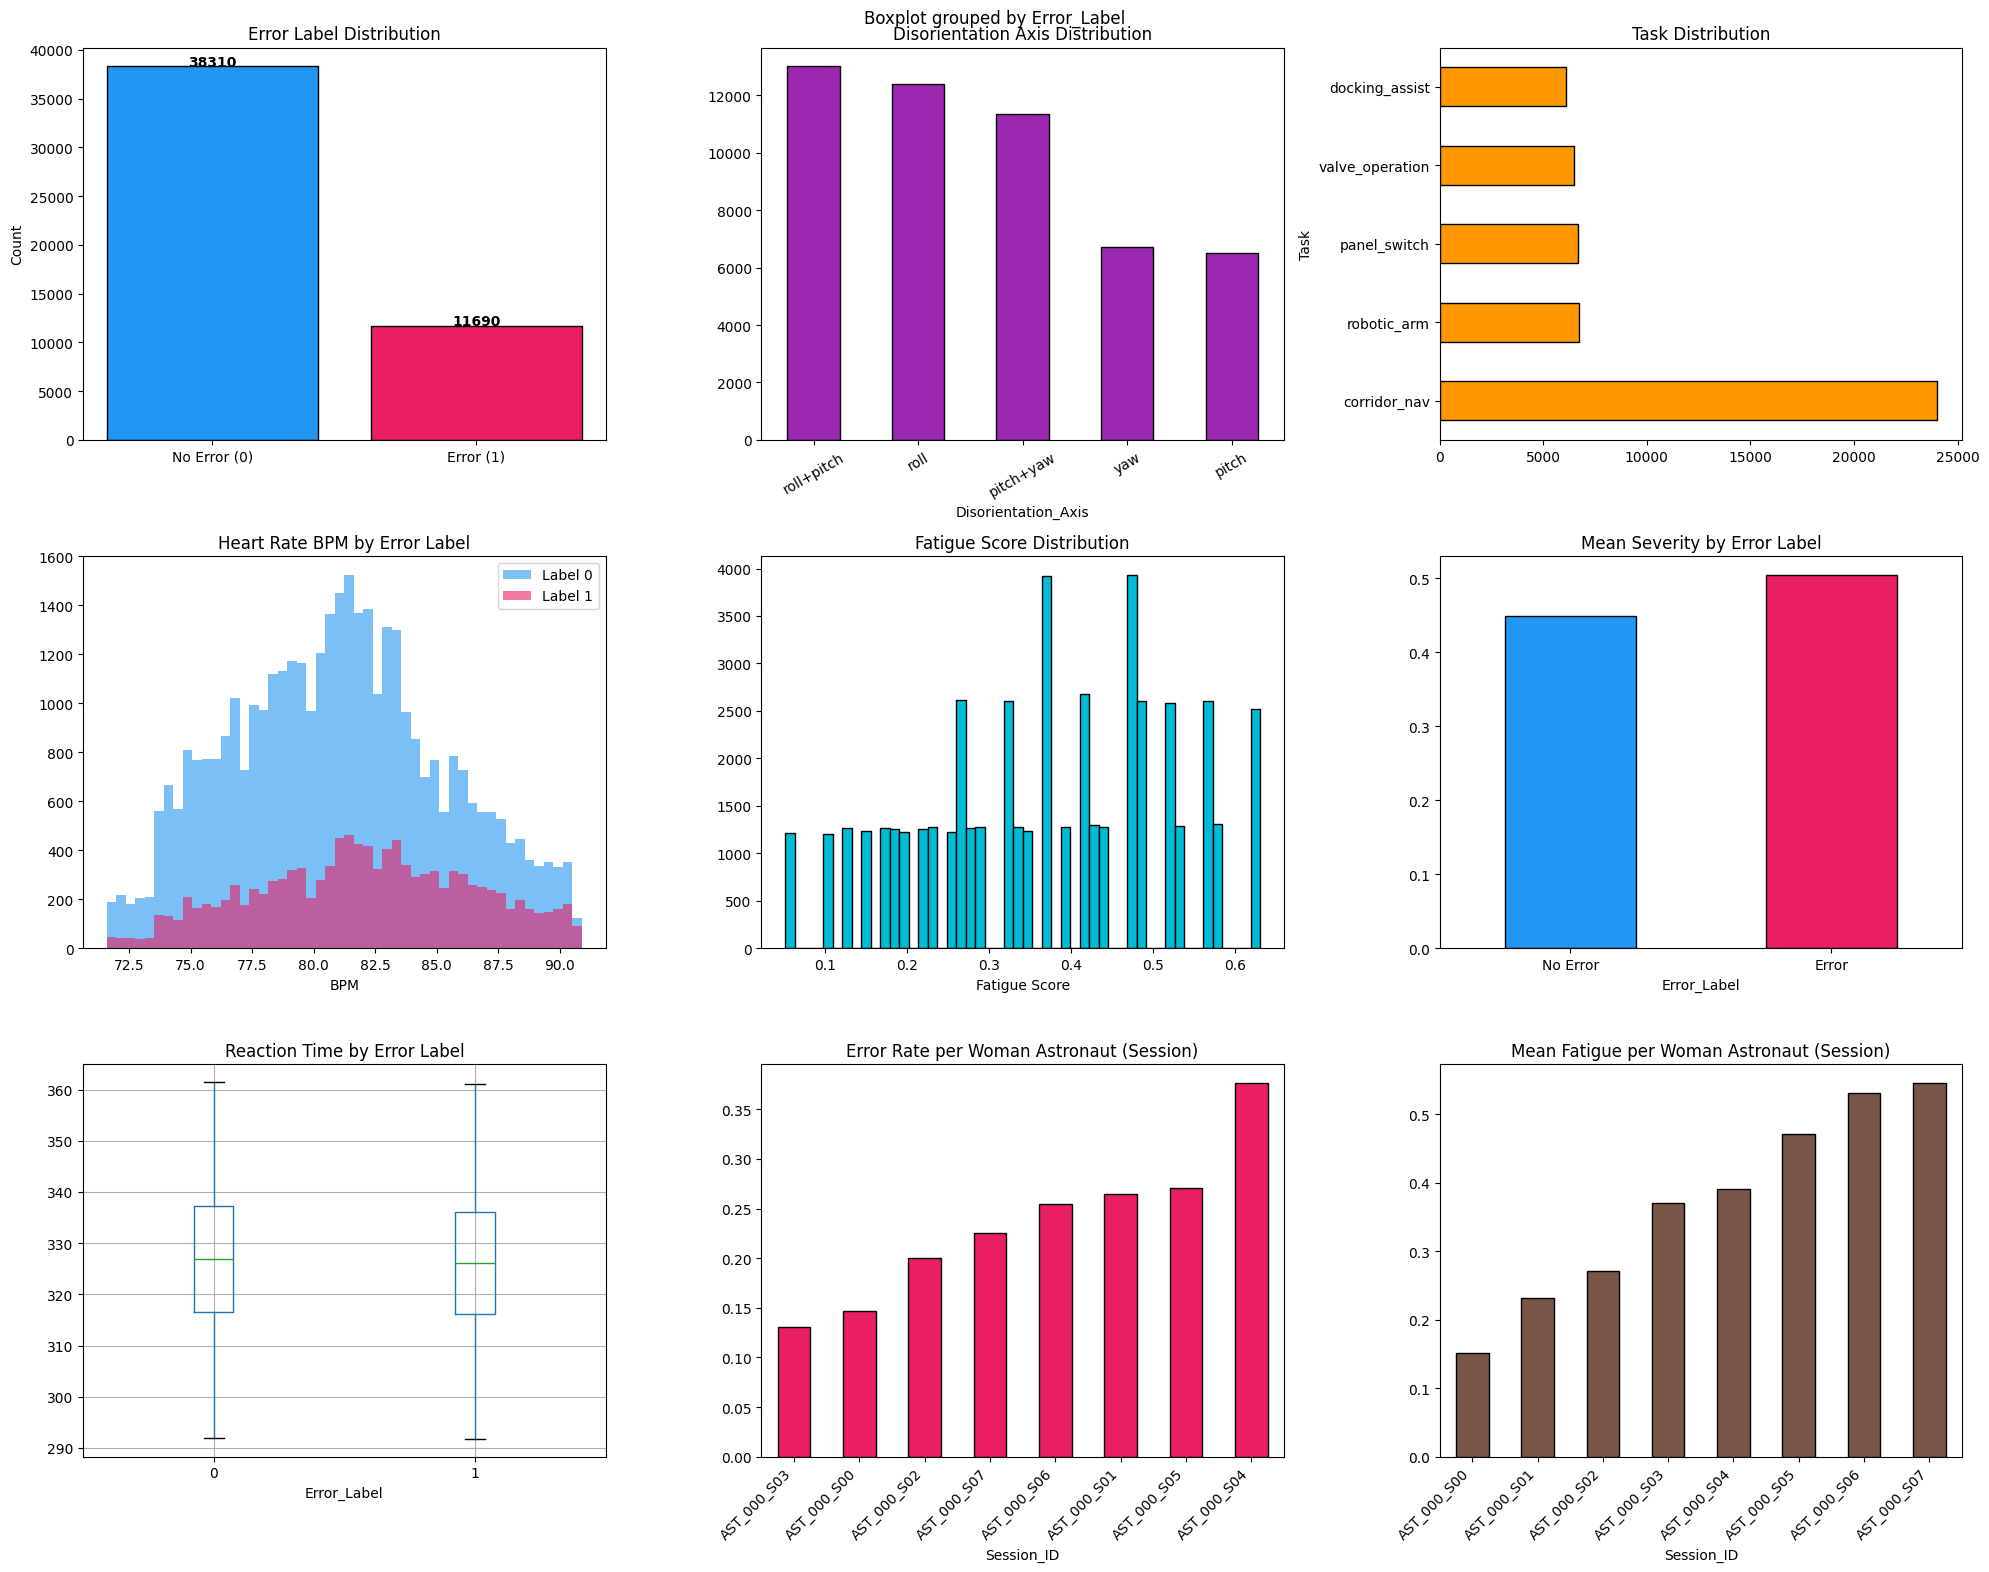

In [ ]:
# ============================================================
# CELL 4: EDA Graphs
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle("SheNav-VR — Astronaut Disorientation EDA (All participants: women)", fontsize=16, fontweight="bold")

ax = axes[0, 0]
counts = df_raw["Error_Label"].value_counts()
ax.bar(["No Error (0)", "Error (1)"], counts.values, color=["#2196F3","#E91E63"], edgecolor="black")
ax.set_title("Error Label Distribution"); ax.set_ylabel("Count")
for i, v in enumerate(counts.values): ax.text(i, v+50, str(v), ha='center', fontweight='bold')

ax = axes[0, 1]
df_raw["Disorientation_Axis"].value_counts().plot(kind="bar", ax=ax, color="#9C27B0", edgecolor="black")
ax.set_title("Disorientation Axis Distribution"); ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

ax = axes[0, 2]
df_raw["Task"].value_counts().plot(kind="barh", ax=ax, color="#FF9800", edgecolor="black")
ax.set_title("Task Distribution")

ax = axes[1, 0]
for label, color in [(0,"#2196F3"),(1,"#E91E63")]:
    ax.hist(df_raw[df_raw["Error_Label"]==label]["Heart_Rate_BPM"],
            bins=50, alpha=0.6, color=color, label=f"Label {label}")
ax.set_title("Heart Rate BPM by Error Label"); ax.legend(); ax.set_xlabel("BPM")

ax = axes[1, 1]
ax.hist(df_raw["Fatigue_Score"], bins=50, color="#00BCD4", edgecolor="black")
ax.set_title("Fatigue Score Distribution"); ax.set_xlabel("Fatigue Score")

ax = axes[1, 2]
df_raw.groupby("Error_Label")["Severity"].mean().plot(kind="bar", ax=ax, color=["#2196F3","#E91E63"], edgecolor="black")
ax.set_title("Mean Severity by Error Label"); ax.set_xticklabels(["No Error","Error"], rotation=0)

ax = axes[2, 0]
df_raw.boxplot(column="Reaction_Time_MS", by="Error_Label", ax=ax)
ax.set_title("Reaction Time by Error Label")

# Per-session (per-woman-astronaut) error rate
ax = axes[2, 1]
df_raw.groupby("Session_ID")["Error_Label"].mean().sort_values().plot(kind="bar", ax=ax, color="#E91E63", edgecolor="black")
ax.set_title("Error Rate per Woman Astronaut (Session)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

ax = axes[2, 2]
df_raw.groupby("Session_ID")["Fatigue_Score"].mean().sort_values().plot(kind="bar", ax=ax, color="#795548", edgecolor="black")
ax.set_title("Mean Fatigue per Woman Astronaut (Session)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout(); plt.show()

=== Per-Astronaut (Session) Statistics ===
Number of woman astronauts (sessions): 8

Error rate per woman astronaut:
Session_ID
AST_000_S00    0.146
AST_000_S01    0.264
AST_000_S02    0.200
AST_000_S03    0.130
AST_000_S04    0.376
AST_000_S05    0.271
AST_000_S06    0.254
AST_000_S07    0.226
Name: Error_Label, dtype: float64

Error rate per task:
Task
panel_switch       0.271
corridor_nav       0.269
valve_operation    0.254
docking_assist     0.146
robotic_arm        0.130
Name: Error_Label, dtype: float64

Error rate per Disorientation_Axis:
Disorientation_Axis
pitch+yaw     0.310
roll+pitch    0.268
pitch         0.254
roll          0.174
yaw           0.130
Name: Error_Label, dtype: float64


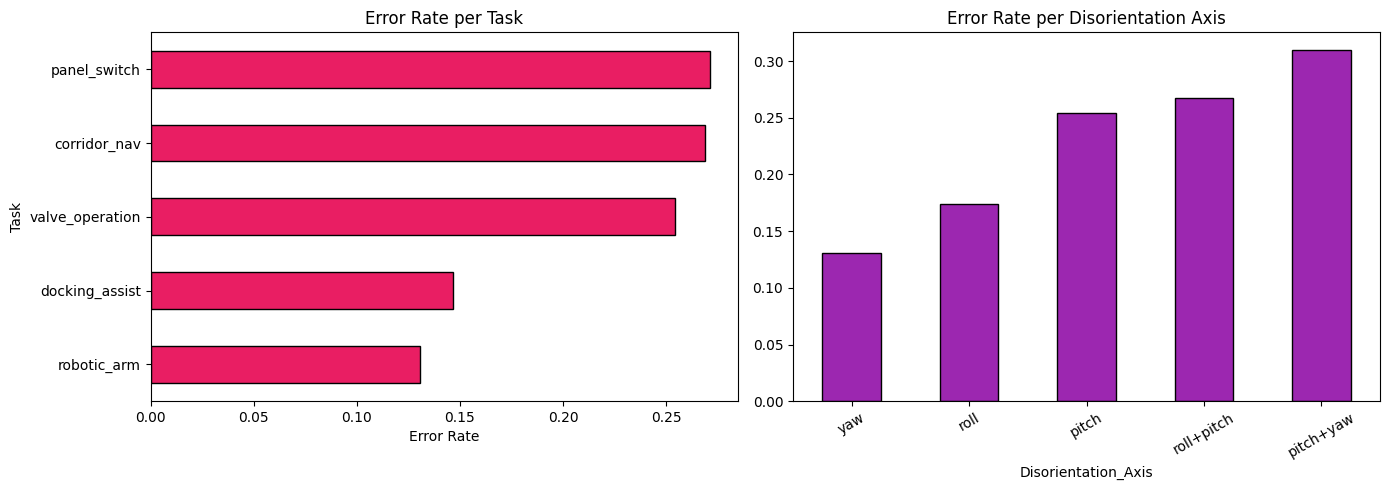

In [ ]:
# ============================================================
# CELL 5: Session (per-astronaut) stats
# ============================================================
# Each session = one woman astronaut
print("=== Per-Astronaut (Session) Statistics ===")
print("Number of woman astronauts (sessions):", df_raw["Session_ID"].nunique())
print("\nError rate per woman astronaut:")
print(df_raw.groupby("Session_ID")["Error_Label"].mean().round(3))
print("\nError rate per task:")
print(df_raw.groupby("Task")["Error_Label"].mean().sort_values(ascending=False).round(3))
print("\nError rate per Disorientation_Axis:")
print(df_raw.groupby("Disorientation_Axis")["Error_Label"].mean().sort_values(ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_raw.groupby("Task")["Error_Label"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#E91E63", edgecolor="black")
axes[0].set_title("Error Rate per Task"); axes[0].set_xlabel("Error Rate")

df_raw.groupby("Disorientation_Axis")["Error_Label"].mean().sort_values().plot(
    kind="bar", ax=axes[1], color="#9C27B0", edgecolor="black")
axes[1].set_title("Error Rate per Disorientation Axis")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
plt.tight_layout(); plt.show()

=== Per-Astronaut (Session) Statistics ===
Number of woman astronauts (sessions): 8

Error rate per woman astronaut:
Session_ID
AST_000_S00    0.146
AST_000_S01    0.264
AST_000_S02    0.200
AST_000_S03    0.130
AST_000_S04    0.376
AST_000_S05    0.271
AST_000_S06    0.254
AST_000_S07    0.226
Name: Error_Label, dtype: float64

Error rate per task:
Task
panel_switch       0.271
corridor_nav       0.269
valve_operation    0.254
docking_assist     0.146
robotic_arm        0.130
Name: Error_Label, dtype: float64

Error rate per Disorientation_Axis:
Disorientation_Axis
pitch+yaw     0.310
roll+pitch    0.268
pitch         0.254
roll          0.174
yaw           0.130
Name: Error_Label, dtype: float64


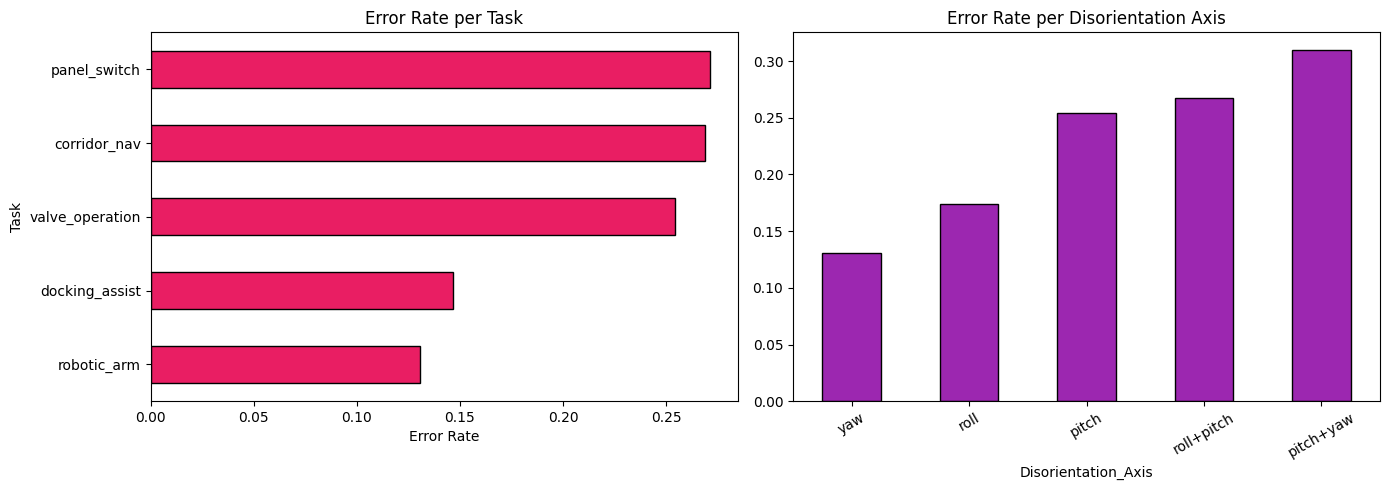

In [ ]:
# ============================================================
# CELL 5: Session (per-astronaut) stats
# ============================================================
# Each session = one woman astronaut
print("=== Per-Astronaut (Session) Statistics ===")
print("Number of woman astronauts (sessions):", df_raw["Session_ID"].nunique())
print("\nError rate per woman astronaut:")
print(df_raw.groupby("Session_ID")["Error_Label"].mean().round(3))
print("\nError rate per task:")
print(df_raw.groupby("Task")["Error_Label"].mean().sort_values(ascending=False).round(3))
print("\nError rate per Disorientation_Axis:")
print(df_raw.groupby("Disorientation_Axis")["Error_Label"].mean().sort_values(ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_raw.groupby("Task")["Error_Label"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#E91E63", edgecolor="black")
axes[0].set_title("Error Rate per Task"); axes[0].set_xlabel("Error Rate")

df_raw.groupby("Disorientation_Axis")["Error_Label"].mean().sort_values().plot(
    kind="bar", ax=axes[1], color="#9C27B0", edgecolor="black")
axes[1].set_title("Error Rate per Disorientation Axis")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 6: Feature Engineering
# ============================================================
df = df_raw.copy()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
# Sort by session (astronaut) then time
df = df.sort_values(["Session_ID", "Timestamp"]).reset_index(drop=True)

# Assign gender = Female for all (all participants are women)
df["Gender"] = "Female"

# Distance to target
df["Distance_To_Target"] = np.sqrt(
    (df["Hand_X"] - df["Target_X"])**2 +
    (df["Hand_Y"] - df["Target_Y"])**2 +
    (df["Hand_Z"] - df["Target_Z"])**2
)

# Operational speed proxy
df["Speed"] = np.sqrt(
    df.groupby("Session_ID")["Hand_X"].diff()**2 +
    df.groupby("Session_ID")["Hand_Y"].diff()**2 +
    df.groupby("Session_ID")["Hand_Z"].diff()**2
).fillna(0)

# Rolling mean distance (10-frame)
df["Rolling_Mean_Distance"] = (
    df.groupby("Session_ID")["Distance_To_Target"]
    .transform(lambda x: x.rolling(10, min_periods=1).mean())
)

# Wrist jitter (3-frame rolling std of speed)
df["Wrist_Jitter"] = (
    df.groupby("Session_ID")["Speed"]
    .transform(lambda x: x.rolling(3, min_periods=1).std())
).fillna(0)

# HR Gradient (derivative of heart rate)
df["HR_Gradient"] = (
    df.groupby("Session_ID")["Heart_Rate_BPM"]
    .transform(lambda x: x.diff())
).fillna(0)

# IMU magnitude
df["IMU_Magnitude"] = np.sqrt(
    df["IMU_Roll_Rate"]**2 + df["IMU_Pitch_Rate"]**2 + df["IMU_Yaw_Rate"]**2
)

# Camera movement magnitude
df["Camera_Movement"] = np.sqrt(
    df["Camera_Roll"]**2 + df["Camera_Pitch"]**2 + df["Camera_Yaw"]**2
)

# Reaction time rolling mean
df["RT_Rolling"] = (
    df.groupby("Session_ID")["Reaction_Time_MS"]
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

print("New features added:", ["Distance_To_Target","Speed","Rolling_Mean_Distance",
                               "Wrist_Jitter","HR_Gradient","IMU_Magnitude","Camera_Movement","RT_Rolling"])
print(df[["Distance_To_Target","Rolling_Mean_Distance","Wrist_Jitter","HR_Gradient"]].describe())

New features added: ['Distance_To_Target', 'Speed', 'Rolling_Mean_Distance', 'Wrist_Jitter', 'HR_Gradient', 'IMU_Magnitude', 'Camera_Movement', 'RT_Rolling']
       Distance_To_Target  Rolling_Mean_Distance  Wrist_Jitter   HR_Gradient
count        50000.000000           50000.000000  50000.000000  50000.000000
mean             0.376533               0.376872      0.038788      0.000298
std              0.273192               0.236856      0.116300      4.098091
min              0.052335               0.074443      0.000000    -10.000000
25%              0.131053               0.182104      0.000846     -2.900000
50%              0.310541               0.333894      0.001831      0.000000
75%              0.583621               0.552254      0.003272      2.900000
max              1.179960               1.162216      0.500143     10.000000


In [ ]:
# ============================================================
# CELL 7: Encode categoricals & scale
# ============================================================
le_axis = LabelEncoder()
le_task = LabelEncoder()
df["Axis_Enc"]        = le_axis.fit_transform(df["Disorientation_Axis"])
df["Axis_Encoded_Int"]= df["Axis_Enc"].copy()   # keep unscaled for haptic target
df["Task_Enc"]        = le_task.fit_transform(df["Task"])

FEATURE_COLS = [
    "IMU_Roll_Rate","IMU_Pitch_Rate","IMU_Yaw_Rate","IMU_Lin_Accel",
    "Hand_X","Hand_Y","Hand_Z","Action_Delta","Visual_Conflict_Score",
    "Reaction_Time_MS","Severity","Fatigue_Score","Camera_Roll","Camera_Pitch","Camera_Yaw",
    "Heart_Rate_BPM","Blink_Rate_Per_Min",
    "Distance_To_Target","Rolling_Mean_Distance","Wrist_Jitter","HR_Gradient",
    "IMU_Magnitude","Camera_Movement","RT_Rolling","Axis_Enc","Task_Enc"
]

scaler = MinMaxScaler()
df[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])
print("Features scaled. Shape:", df[FEATURE_COLS].shape)
print("Feature count:", len(FEATURE_COLS))

Features scaled. Shape: (50000, 26)
Feature count: 26


In [ ]:
# ============================================================
# CELL 8: Build sequences (20-frame windows, per session = per astronaut)
# Each session is treated as one distinct woman astronaut
# ============================================================
SEQ_LEN = 20

def build_sequences(data, feature_cols, seq_len=20):
    """
    Build sliding-window sequences.
    Grouping is by Session_ID — each session = one woman astronaut.
    """
    X_list, y_list, meta_list = [], [], []
    for session_id, grp in data.groupby("Session_ID"):
        grp = grp.reset_index(drop=True)
        feats       = grp[feature_cols].values
        labels      = grp["Error_Label"].values
        fatigue     = grp["Fatigue_Score"].values
        axis_enc_int= grp["Axis_Encoded_Int"].values
        for i in range(len(grp) - seq_len):
            X_list.append(feats[i:i+seq_len])
            y_list.append(labels[i+seq_len])
            meta_list.append({
                "Fatigue" : fatigue[i+seq_len],
                "Axis"    : axis_enc_int[i+seq_len],
                "Session" : session_id            # session = astronaut
            })
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), meta_list

X, y, meta = build_sequences(df, FEATURE_COLS, SEQ_LEN)
print(f"Sequence shape: {X.shape}  |  Labels: {y.shape}")
print(f"Class balance — Error: {y.mean():.3f}  No-Error: {1-y.mean():.3f}")

Sequence shape: (49840, 20, 26)  |  Labels: (49840,)
Class balance — Error: 0.235  No-Error: 0.765


In [ ]:
# ============================================================
# CELL 9: Train / Val / Test split
# ============================================================
X_trainval, X_test, y_trainval, y_test, meta_trainval, meta_test = train_test_split(
    X, y, meta, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_trainval, y_trainval, meta_trainval, test_size=0.15, random_state=SEED, stratify=y_trainval)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (36009, 20, 26) | Val: (6355, 20, 26) | Test: (7476, 20, 26)


In [ ]:
# ============================================================
# CELL 10: Dataset & DataLoader (batch_size=1 for inference)
# ============================================================
class AstroDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 256
train_loader = DataLoader(AstroDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(AstroDataset(X_val,   y_val),   batch_size=BATCH)
test_loader  = DataLoader(AstroDataset(X_test,  y_test),  batch_size=BATCH)

# Batch-size=1 inference loader (for real-time / edge deployment)
infer_loader = DataLoader(AstroDataset(X_test, y_test), batch_size=1)
print("Batch-size-1 inference loader ready. Samples:", len(infer_loader))

Batch-size-1 inference loader ready. Samples: 7476


In [ ]:
# ============================================================
# CELL 11: 2-Layer LSTM Architecture
#   General model  +  Personal adapter head
#   Hidden-state reuse  +  Circular buffer
# ============================================================

class CircularBuffer:
    """
    Fixed-size circular buffer for streaming sensor frames.
    Enables sliding-window inference without re-allocating arrays.
    """
    def __init__(self, capacity: int, feature_dim: int):
        self.capacity    = capacity
        self.feature_dim = feature_dim
        self.buffer      = np.zeros((capacity, feature_dim), dtype=np.float32)
        self.ptr         = 0
        self.filled      = False

    def push(self, frame: np.ndarray):
        """Push one frame (shape: [feature_dim])."""
        self.buffer[self.ptr] = frame
        self.ptr = (self.ptr + 1) % self.capacity
        if self.ptr == 0:
            self.filled = True

    def get_window(self) -> np.ndarray:
        """
        Return the last `capacity` frames in chronological order.
        Returns None if buffer not yet full.
        """
        if not self.filled and self.ptr < self.capacity:
            return None
        return np.concatenate([
            self.buffer[self.ptr:],
            self.buffer[:self.ptr]
        ], axis=0)


class CognitiveTwinLSTM(nn.Module):
    """
    2-layer LSTM general model with:
    - Attention mechanism for explainability
    - Personal adapter head (fine-tuned per astronaut)
    - Hidden-state reuse for efficient streaming inference
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        assert num_layers == 2, "Architecture requires exactly 2 LSTM layers"

        # ── General model (frozen after pre-training for personalization) ──
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Temporal attention (for explainability visualization)
        self.attention = nn.Linear(hidden_size, 1)

        # ── Personal adapter head (fine-tuned per astronaut) ──
        self.adapter_head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        # Cached hidden state for streaming (hidden-state reuse)
        self._h = None
        self._c = None

    def forward(self, x, reuse_hidden=False):
        """
        x: (B, T, input_size)
        reuse_hidden: if True, pass cached hidden state → hidden-state reuse
        """
        if reuse_hidden and self._h is not None and x.size(0) == 1:
            out, (h, c) = self.lstm(x, (self._h, self._c))
        else:
            out, (h, c) = self.lstm(x)

        # Cache for next call (only meaningful for batch_size=1 streaming)
        self._h = h.detach()
        self._c = c.detach()

        # Temporal attention
        attn_w  = torch.softmax(self.attention(out), dim=1)   # (B, T, 1)
        context = (attn_w * out).sum(dim=1)                   # (B, H)

        return self.adapter_head(context).squeeze(1), attn_w.squeeze(-1)

    def reset_hidden(self):
        self._h = None
        self._c = None

    def get_attention_weights(self, x):
        """Return attention weights for visualization (no grad)."""
        self.eval()
        with torch.no_grad():
            _, attn = self.forward(x)
        return attn.cpu().numpy()


INPUT_SIZE = len(FEATURE_COLS)
model = CognitiveTwinLSTM(INPUT_SIZE).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"LSTM layers: 2  (general model)")
print(f"Adapter head: Linear(128→64→1)  (personal, fine-tuned per astronaut)")

CognitiveTwinLSTM(
  (lstm): LSTM(26, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (adapter_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total parameters: 220,418
LSTM layers: 2  (general model)
Adapter head: Linear(128→64→1)  (personal, fine-tuned per astronaut)


In [ ]:
# ============================================================
# CELL 12: Haptic Classifier (auxiliary lightweight FFN)
# ============================================================
class HapticClassifier(nn.Module):
    """Classifies orientation axis failure type from a single frame."""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x): return self.net(x)

axis_classes  = df["Disorientation_Axis"].nunique()
haptic_model  = HapticClassifier(INPUT_SIZE, axis_classes).to(device)
print(f"HapticClassifier — {axis_classes} axis classes: {le_axis.classes_.tolist()}")

HapticClassifier — 5 axis classes: ['pitch', 'pitch+yaw', 'roll', 'roll+pitch', 'yaw']


In [ ]:
# ============================================================
# CELL 13: Weight Pruning utility
# ============================================================
import torch.nn.utils.prune as prune

def apply_weight_pruning(module, amount=0.2):
    """
    Unstructured L1 pruning on all Linear and LSTM weight matrices.
    `amount` = fraction of weights to zero out (20% by default).
    """
    for name, mod in module.named_modules():
        if isinstance(mod, nn.Linear):
            prune.l1_unstructured(mod, name="weight", amount=amount)
            prune.remove(mod, "weight")   # make permanent
            print(f"  Pruned {name} (Linear) — {amount*100:.0f}% zeros")
        elif isinstance(mod, nn.LSTM):
            for pname in [n for n, _ in mod.named_parameters() if "weight" in n]:
                prune.l1_unstructured(mod, name=pname, amount=amount)
                prune.remove(mod, pname)
                print(f"  Pruned {name}.{pname} (LSTM) — {amount*100:.0f}% zeros")

def sparsity_report(module):
    total, zeros = 0, 0
    for p in module.parameters():
        total += p.numel()
        zeros += (p == 0).sum().item()
    print(f"  Sparsity: {zeros/total*100:.1f}%  ({zeros}/{total} weights zeroed)")

print("Weight pruning utility ready.")
print("Usage: apply_weight_pruning(model, amount=0.2)  — run AFTER training")

Weight pruning utility ready.
Usage: apply_weight_pruning(model, amount=0.2)  — run AFTER training


In [ ]:
# ============================================================
# CELL 14: SIMD/DSP-Friendly Execution helpers
# ============================================================
def make_simd_friendly(tensor: torch.Tensor) -> torch.Tensor:
    """
    Ensure tensor is contiguous and aligned to 16-element (64-byte) boundaries
    for SIMD / vectorised execution on DSP / embedded CPUs.
    Pads the feature dim to the nearest multiple of 16 if needed.
    """
    feat_dim = tensor.shape[-1]
    pad_to = ((feat_dim + 15) // 16) * 16
    if pad_to != feat_dim:
        pad = torch.zeros(*tensor.shape[:-1], pad_to - feat_dim)
        tensor = torch.cat([tensor, pad], dim=-1)
    return tensor.contiguous()

def batch1_infer_simd(model, frame_buffer: np.ndarray, reuse_hidden=True) -> float:
    """
    Batch-size=1, SIMD-aligned, hidden-state-reusing inference.
    frame_buffer: numpy array of shape (SEQ_LEN, features)
    Returns: probability float
    """
    t = torch.tensor(frame_buffer, dtype=torch.float32).unsqueeze(0)  # (1, T, F)
    t = make_simd_friendly(t)
    # Trim back to original feature size if padded
    t = t[:, :, :INPUT_SIZE]
    model.eval()
    with torch.no_grad():
        prob, _ = model(t.cpu(), reuse_hidden=reuse_hidden)
    return prob.item()

print("SIMD/DSP-friendly execution helpers ready.")
print(f"Feature dim {INPUT_SIZE} → padded to {((INPUT_SIZE+15)//16)*16} for 16-wide SIMD")

SIMD/DSP-friendly execution helpers ready.
Feature dim 26 → padded to 32 for 16-wide SIMD


In [ ]:
# ============================================================
# CELL 15: Train CognitiveTwin LSTM (General Model)
# ============================================================
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)
criterion  = nn.BCELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

EPOCHS = 10
train_losses, val_losses, val_f1s = [], [], []
best_f1, best_state = 0, None

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, _ = model(xb)
        weights = torch.where(yb == 1, pos_weight.squeeze(), torch.ones_like(yb))
        loss = (weights * F.binary_cross_entropy(pred, yb, reduction="none")).mean()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_preds, val_true = [], []
    v_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, _ = model(xb)
            v_loss += F.binary_cross_entropy(pred, yb).item()
            val_preds.extend(pred.cpu().numpy())
            val_true.extend(yb.cpu().numpy())

    val_preds_bin = (np.array(val_preds) >= 0.55).astype(int)
    f1 = f1_score(val_true, val_preds_bin, zero_division=0)
    train_losses.append(running_loss / len(train_loader))
    val_losses.append(v_loss / len(val_loader))
    val_f1s.append(f1)
    scheduler.step(v_loss / len(val_loader))

    if f1 > best_f1:
        best_f1 = f1
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {running_loss/len(train_loader):.4f} "
          f"| Val Loss: {v_loss/len(val_loader):.4f} | Val F1: {f1:.4f}")

model.load_state_dict(best_state)
print(f"\nBest Val F1: {best_f1:.4f}")

Epoch 01/10 | Train Loss: 0.6181 | Val Loss: 0.2060 | Val F1: 0.8818
Epoch 02/10 | Train Loss: 0.2501 | Val Loss: 0.1274 | Val F1: 0.9048
Epoch 03/10 | Train Loss: 0.2042 | Val Loss: 0.1912 | Val F1: 0.8510
Epoch 04/10 | Train Loss: 0.1764 | Val Loss: 0.0909 | Val F1: 0.9374
Epoch 05/10 | Train Loss: 0.1487 | Val Loss: 0.0857 | Val F1: 0.9339
Epoch 06/10 | Train Loss: 0.1532 | Val Loss: 0.0868 | Val F1: 0.9365
Epoch 07/10 | Train Loss: 0.1246 | Val Loss: 0.0925 | Val F1: 0.9385
Epoch 08/10 | Train Loss: 0.1187 | Val Loss: 0.0775 | Val F1: 0.9409
Epoch 09/10 | Train Loss: 0.1115 | Val Loss: 0.0702 | Val F1: 0.9455
Epoch 10/10 | Train Loss: 0.1108 | Val Loss: 0.0602 | Val F1: 0.9527

Best Val F1: 0.9527


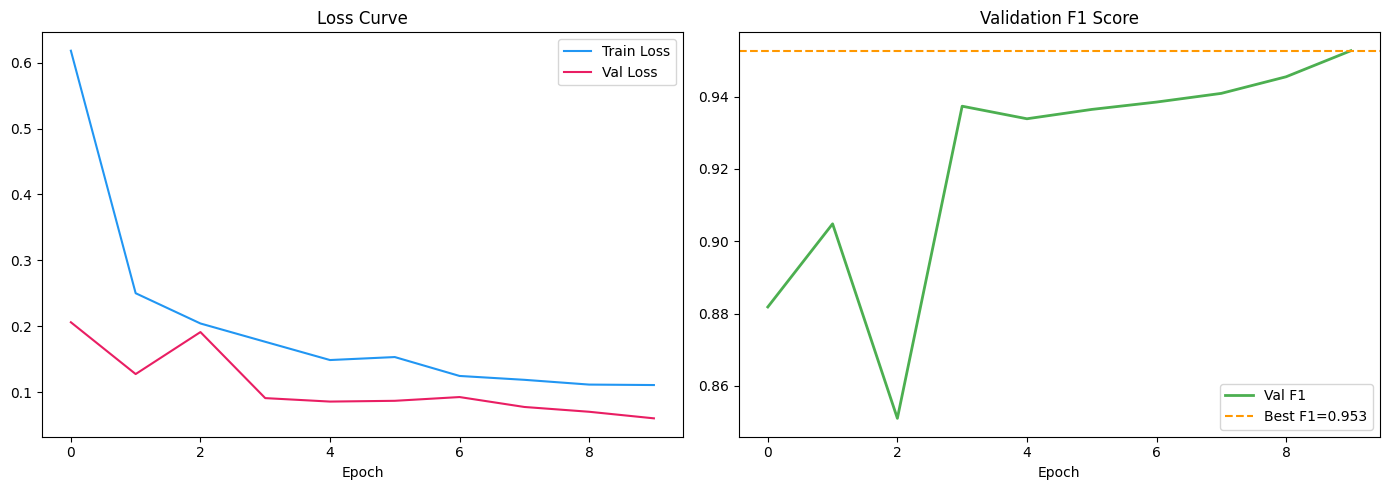

In [ ]:
# ============================================================
# CELL 16: Training curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label="Train Loss", color="#2196F3")
axes[0].plot(val_losses,   label="Val Loss",   color="#E91E63")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(val_f1s, label="Val F1", color="#4CAF50", linewidth=2)
axes[1].axhline(y=best_f1, linestyle="--", color="#FF9800", label=f"Best F1={best_f1:.3f}")
axes[1].set_title("Validation F1 Score"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 17: Personal Adapter Fine-Tuning
#   Freeze LSTM (general model), fine-tune adapter head per astronaut
#   Each session = one woman astronaut
# ============================================================
# Freeze LSTM layers (general model stays frozen)
for name, param in model.named_parameters():
    if "lstm" in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after freeze: {trainable:,} (adapter head only)")

SESSIONS = df["Session_ID"].unique()
print(f"\nFine-tuning personal adapters for {len(SESSIONS)} woman astronauts...")

personal_models = {}   # session_id → fine-tuned model state

for ast_session in SESSIONS:
    df_ast = df[df["Session_ID"] == ast_session]
    X_ast, y_ast, _ = build_sequences(df_ast, FEATURE_COLS, SEQ_LEN)

    if len(X_ast) < SEQ_LEN + 10:
        print(f"  {ast_session}: too few sequences, skipping.")
        continue

    X_atr, X_avl, y_atr, y_avl = train_test_split(
        X_ast, y_ast, test_size=0.2, random_state=SEED)
    ft_loader = DataLoader(AstroDataset(X_atr, y_atr), batch_size=32, shuffle=True)
    ft_opt    = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)

    model.train()
    for ep in range(5):
        for xb, yb in ft_loader:
            xb, yb = xb.to(device), yb.to(device)
            ft_opt.zero_grad()
            pred, _ = model(xb)
            loss = F.binary_cross_entropy(pred, yb)
            loss.backward(); ft_opt.step()

    personal_models[ast_session] = copy.deepcopy(model.state_dict())
    print(f"  {ast_session}: personal adapter trained ✅")

# Unfreeze for general use
for param in model.parameters():
    param.requires_grad = True

print(f"\nPersonal adapters trained for {len(personal_models)} woman astronauts.")

Trainable params after freeze: 8,450 (adapter head only)

Fine-tuning personal adapters for 8 woman astronauts...
  AST_000_S00: personal adapter trained ✅
  AST_000_S01: personal adapter trained ✅
  AST_000_S02: personal adapter trained ✅
  AST_000_S03: personal adapter trained ✅
  AST_000_S04: personal adapter trained ✅
  AST_000_S05: personal adapter trained ✅
  AST_000_S06: personal adapter trained ✅
  AST_000_S07: personal adapter trained ✅

Personal adapters trained for 8 woman astronauts.


In [ ]:
# ============================================================
# CELL 18: Apply Weight Pruning (post-training)
# ============================================================
print("=== Applying Weight Pruning (20%) ===")
apply_weight_pruning(model, amount=0.2)
sparsity_report(model)

=== Applying Weight Pruning (20%) ===
  Pruned lstm.weight_ih_l0 (LSTM) — 20% zeros
  Pruned lstm.weight_hh_l0 (LSTM) — 20% zeros
  Pruned lstm.weight_ih_l1 (LSTM) — 20% zeros
  Pruned lstm.weight_hh_l1 (LSTM) — 20% zeros
  Pruned attention (Linear) — 20% zeros
  Pruned adapter_head.0 (Linear) — 20% zeros
  Pruned adapter_head.3 (Linear) — 20% zeros
  Sparsity: 19.8%  (43660/220418 weights zeroed)


In [ ]:
# ============================================================
# CELL 19: Train HapticClassifier
# ============================================================
X_haptic  = X[:, -1, :]                                 # last frame of each window
y_haptic  = np.array([m["Axis"] for m in meta])

X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_haptic, y_haptic, test_size=0.2, random_state=SEED, stratify=y_haptic)

class HapticDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

h_tr_loader = DataLoader(HapticDataset(X_h_tr, y_h_tr), batch_size=256, shuffle=True)
h_te_loader = DataLoader(HapticDataset(X_h_te, y_h_te), batch_size=256)

h_criterion = nn.CrossEntropyLoss()
h_opt = torch.optim.Adam(haptic_model.parameters(), lr=1e-3)

for ep in range(15):
    haptic_model.train()
    for xb, yb in h_tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        h_opt.zero_grad()
        out  = haptic_model(xb)
        loss = h_criterion(out, yb)
        loss.backward(); h_opt.step()

haptic_model.eval()
all_preds_h, all_true_h = [], []
with torch.no_grad():
    for xb, yb in h_te_loader:
        preds = haptic_model(xb.to(device)).argmax(dim=1).cpu().numpy()
        all_preds_h.extend(preds); all_true_h.extend(yb.numpy())

print("HapticClassifier Report:")
print(classification_report(all_true_h, all_preds_h, target_names=le_axis.classes_))

HapticClassifier Report:
              precision    recall  f1-score   support

       pitch       1.00      1.00      1.00      1298
   pitch+yaw       1.00      1.00      1.00      2264
        roll       1.00      1.00      1.00      2473
  roll+pitch       1.00      1.00      1.00      2595
         yaw       1.00      1.00      1.00      1338

    accuracy                           1.00      9968
   macro avg       1.00      1.00      1.00      9968
weighted avg       1.00      1.00      1.00      9968



In [ ]:
# ============================================================
# CELL 20: INT8 Dynamic Quantization + Sliding Window Inference
# ============================================================

# ── INT8 Quantization ──
model_cpu  = model.cpu()
model_int8 = torch.quantization.quantize_dynamic(
    model_cpu, {nn.LSTM, nn.Linear}, dtype=torch.qint8
)

torch.save(model_cpu.state_dict(),  "/tmp/model_fp32.pt")
torch.save(model_int8.state_dict(), "/tmp/model_int8.pt")

fp32_size = os.path.getsize("/tmp/model_fp32.pt") / 1024
int8_size = os.path.getsize("/tmp/model_int8.pt") / 1024
print(f"Float32 size: {fp32_size:.1f} KB | INT8 size: {int8_size:.1f} KB "
      f"| Compression: {fp32_size/int8_size:.2f}x")

# ── Sliding Window Inference with Circular Buffer ──
print("\n=== Sliding Window Inference with Circular Buffer ===")
session_id  = SESSIONS[0]
df_stream   = df[df["Session_ID"] == session_id].reset_index(drop=True)
stream_feats = df_stream[FEATURE_COLS].values.astype(np.float32)

cbuf = CircularBuffer(capacity=SEQ_LEN, feature_dim=INPUT_SIZE)
model_int8.eval()
model.reset_hidden()

sw_probs = []
for i, frame in enumerate(stream_feats[:300]):
    cbuf.push(frame)
    window = cbuf.get_window()
    if window is None:
        continue                          # buffer not full yet
    prob = batch1_infer_simd(model_int8, window, reuse_hidden=False)
    sw_probs.append(prob)
    if i % 50 == 0:
        print(f"  Frame {i:3d} | P(error)={prob:.3f}")

print(f"\nSliding window inference complete — {len(sw_probs)} predictions.")

Float32 size: 866.2 KB | INT8 size: 229.4 KB | Compression: 3.78x

=== Sliding Window Inference with Circular Buffer ===
  Frame  50 | P(error)=0.000
  Frame 100 | P(error)=0.000
  Frame 150 | P(error)=0.003
  Frame 200 | P(error)=0.000
  Frame 250 | P(error)=0.000

Sliding window inference complete — 281 predictions.


In [ ]:
# ============================================================
# CELL 21: Full Test Evaluation (Float32 vs INT8)
# ============================================================
model_cpu.eval()
all_probs, all_true_test = [], []
with torch.no_grad():
    for xb, yb in DataLoader(AstroDataset(X_test, y_test), batch_size=256):
        prob, _ = model_cpu(xb)
        all_probs.extend(prob.numpy())
        all_true_test.extend(yb.numpy())

all_probs      = np.array(all_probs)
all_true_test  = np.array(all_true_test)
preds_55       = (all_probs >= 0.55).astype(int)
f1_fp32        = f1_score(all_true_test, preds_55)

model_int8.eval()
int8_probs = []
with torch.no_grad():
    for xb, yb in DataLoader(AstroDataset(X_test, y_test), batch_size=256):
        out, _ = model_int8(xb)
        int8_probs.extend(out.numpy())

int8_probs = np.array(int8_probs)
preds_int8 = (int8_probs >= 0.55).astype(int)
f1_int8    = f1_score(all_true_test, preds_int8)
f1_drop    = abs(f1_fp32 - f1_int8)

print("=== Float32 Model ===")
print(classification_report(all_true_test, preds_55, target_names=["No Error","Error"]))
print(f"F1 @ 0.55: {f1_fp32:.4f}")
print(f"\nINT8 F1: {f1_int8:.4f} | Drop: {f1_drop:.4f} "
      f"({'✅ Within 2%' if f1_drop < 0.02 else '⚠️ Exceeds 2%'})")

=== Float32 Model ===
              precision    recall  f1-score   support

    No Error       0.98      0.99      0.99      5723
       Error       0.98      0.94      0.96      1753

    accuracy                           0.98      7476
   macro avg       0.98      0.97      0.97      7476
weighted avg       0.98      0.98      0.98      7476

F1 @ 0.55: 0.9581

INT8 F1: 0.9584 | Drop: 0.0003 (✅ Within 2%)


Best threshold: 0.300  F1: 0.9658


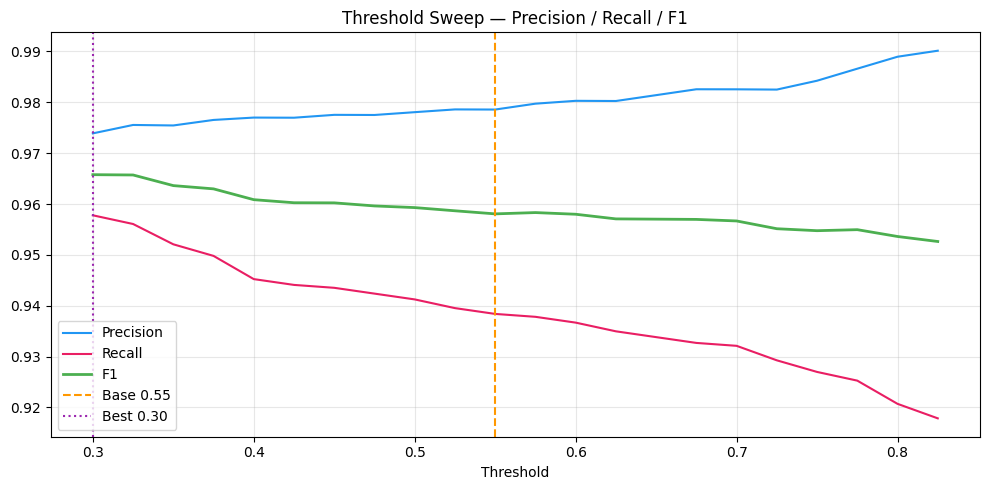

Fatigue=0.0 → Threshold=0.550
Fatigue=0.3 → Threshold=0.505
Fatigue=0.6 → Threshold=0.460
Fatigue=0.9 → Threshold=0.415


In [ ]:
# ============================================================
# CELL 22: Threshold Sweep + Fatigue-Adaptive Adjustment
# ============================================================
def adaptive_threshold(base=0.55, fatigue_score=0.0):
    """Lower threshold when fatigue is high (more protective)."""
    return max(0.35, base - 0.15 * fatigue_score)

thresholds = np.arange(0.3, 0.85, 0.025)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred_t = (all_probs >= t).astype(int)
    precisions.append(precision_score(all_true_test, pred_t, zero_division=0))
    recalls.append(recall_score(all_true_test, pred_t, zero_division=0))
    f1s.append(f1_score(all_true_test, pred_t, zero_division=0))

best_idx = np.argmax(f1s)
print(f"Best threshold: {thresholds[best_idx]:.3f}  F1: {f1s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label="Precision", color="#2196F3")
ax.plot(thresholds, recalls,    label="Recall",    color="#E91E63")
ax.plot(thresholds, f1s,        label="F1",        color="#4CAF50", linewidth=2)
ax.axvline(x=0.55, linestyle="--", color="#FF9800", label="Base 0.55")
ax.axvline(x=thresholds[best_idx], linestyle=":", color="#9C27B0",
           label=f"Best {thresholds[best_idx]:.2f}")
ax.set_title("Threshold Sweep — Precision / Recall / F1")
ax.legend(); ax.set_xlabel("Threshold"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for fs in [0.0, 0.3, 0.6, 0.9]:
    print(f"Fatigue={fs:.1f} → Threshold={adaptive_threshold(0.55, fs):.3f}")

In [ ]:
# ============================================================
# CELL 23: Haptic Intervention Logic
# ============================================================
HAPTIC_PATTERNS = {
    "roll":      "Short-Short-LONG  (establish mechanical reference)",
    "pitch":     "Short-Short-Short (path alignment correction)",
    "yaw":       "Short-Short-Short (path alignment correction)",
    "all":       "LONG-Short        (FREEZE — wait for sensory recovery)",
    "none":      "No haptic needed",
    "default":   "Short-Short-LONG  (general orientation alert)"
}
COOLDOWN_SECS = 3.0

class HapticController:
    def __init__(self, cooldown=3.0):
        self.cooldown       = cooldown
        self.last_alert_time = -999
        self.alert_log      = []

    def trigger(self, t, prob, axis_label, fatigue):
        thresh = adaptive_threshold(0.55, fatigue)
        if prob < thresh:                             return None
        if (t - self.last_alert_time) < self.cooldown: return None
        self.last_alert_time = t
        pattern = HAPTIC_PATTERNS.get(axis_label, HAPTIC_PATTERNS["default"])
        self.alert_log.append({"time": t, "prob": prob, "axis": axis_label, "pattern": pattern})
        return pattern

ctrl = HapticController()
print("=== Haptic Trigger Demo ===")
for t, p, ax_lbl, fat in [
    (0.0, 0.72, "roll",  0.2),
    (1.0, 0.81, "pitch", 0.5),
    (2.5, 0.90, "all",   0.9),
    (5.0, 0.65, "yaw",   0.3),
    (5.5, 0.70, "roll",  0.3),
    (8.0, 0.88, "all",   0.8),
]:
    result = ctrl.trigger(t, p, ax_lbl, fat)
    print(f"  t={t:.1f}s | P={p:.2f} | Axis={ax_lbl:5s} | Fatigue={fat} → "
          f"{result if result else '⏸ SUPPRESSED (cooldown)'}")

=== Haptic Trigger Demo ===
  t=0.0s | P=0.72 | Axis=roll  | Fatigue=0.2 → Short-Short-LONG  (establish mechanical reference)
  t=1.0s | P=0.81 | Axis=pitch | Fatigue=0.5 → ⏸ SUPPRESSED (cooldown)
  t=2.5s | P=0.90 | Axis=all   | Fatigue=0.9 → ⏸ SUPPRESSED (cooldown)
  t=5.0s | P=0.65 | Axis=yaw   | Fatigue=0.3 → Short-Short-Short (path alignment correction)
  t=5.5s | P=0.70 | Axis=roll  | Fatigue=0.3 → ⏸ SUPPRESSED (cooldown)
  t=8.0s | P=0.88 | Axis=all   | Fatigue=0.8 → LONG-Short        (FREEZE — wait for sensory recovery)


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values shape: (20, 26)


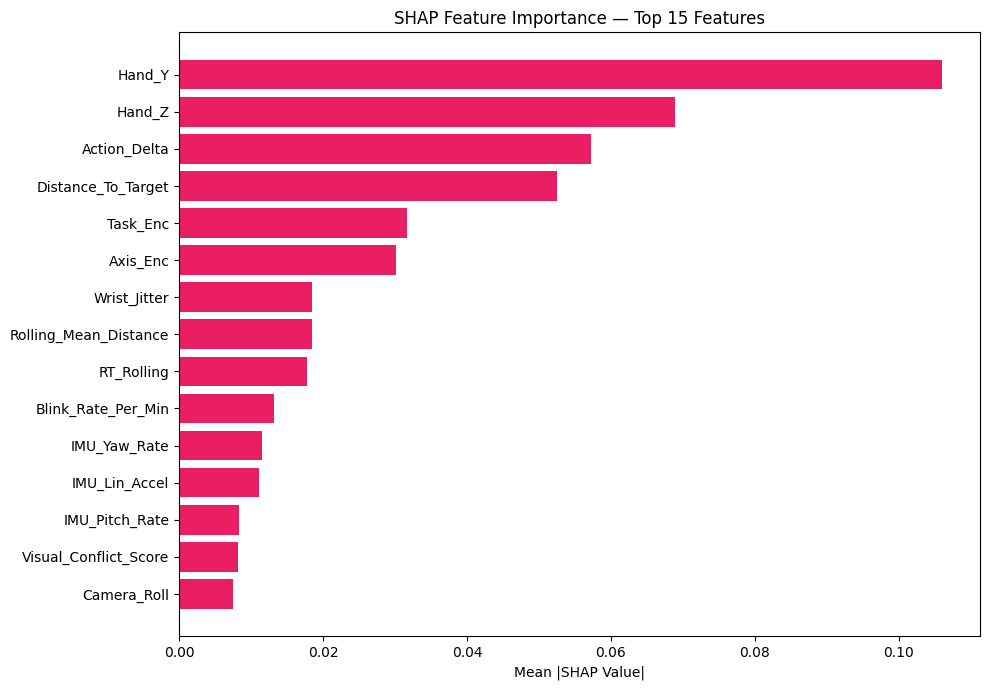


Generating SHAP beeswarm plot...


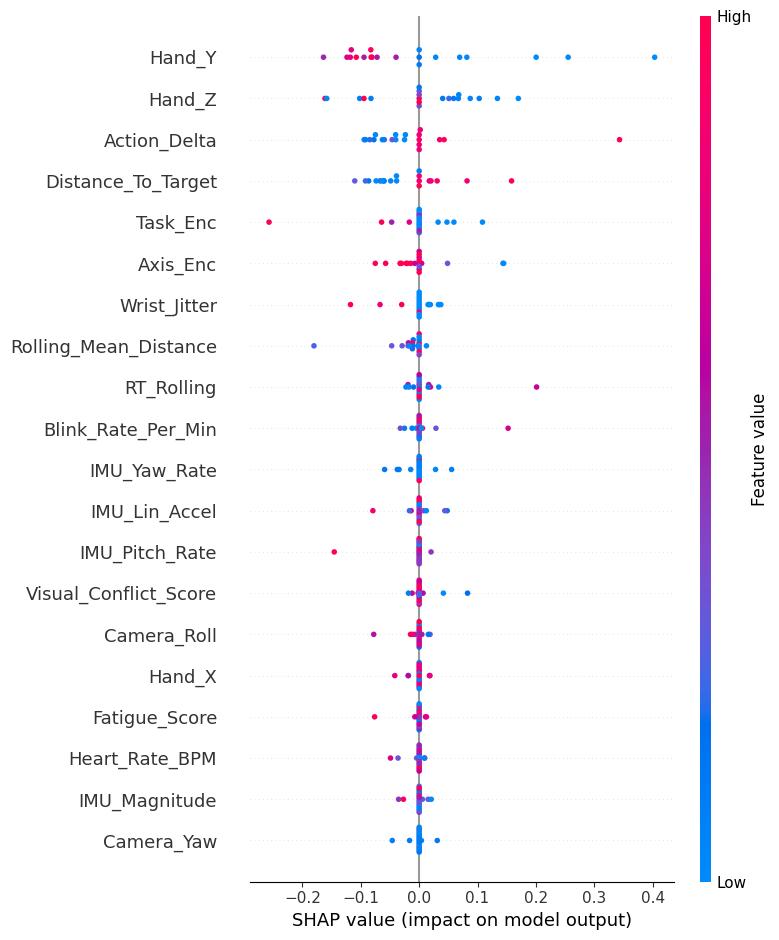

In [ ]:
# ============================================================
# CELL 24: SHAP Explanations
# ============================================================
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed — run: pip install shap")

if HAS_SHAP:
    # SHAP requires a function that takes numpy → numpy
    def model_predict_shap(X_np):
        """Wrapper for SHAP: last-frame features → probability."""
        t = torch.tensor(X_np, dtype=torch.float32)
        model_cpu.eval()
        with torch.no_grad():
            # Repeat last frame SEQ_LEN times to form a dummy sequence
            seq = t.unsqueeze(1).expand(-1, SEQ_LEN, -1)
            probs, _ = model_cpu(seq)
        return probs.numpy()

    # Use a small background (100 samples) for efficiency
    background = X_train[:100, -1, :]          # last frame
    explainer  = shap.KernelExplainer(model_predict_shap, background)

    X_explain  = X_test[:20, -1, :]            # explain 20 test samples
    shap_vals  = explainer.shap_values(X_explain, nsamples=50)

    print("SHAP values shape:", np.array(shap_vals).shape)

    # ── SHAP Bar Plot (mean |SHAP|) ──
    fig, ax = plt.subplots(figsize=(10, 7))
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    sorted_idx    = np.argsort(mean_abs_shap)[::-1][:15]
    ax.barh(
        [FEATURE_COLS[i] for i in sorted_idx[::-1]],
        mean_abs_shap[sorted_idx[::-1]],
        color="#E91E63"
    )
    ax.set_title("SHAP Feature Importance — Top 15 Features")
    ax.set_xlabel("Mean |SHAP Value|")
    plt.tight_layout(); plt.show()

    # ── SHAP Summary (beeswarm) ──
    print("\nGenerating SHAP beeswarm plot...")
    shap.summary_plot(shap_vals, X_explain, feature_names=FEATURE_COLS, show=True)

=== High-Error Sample ===


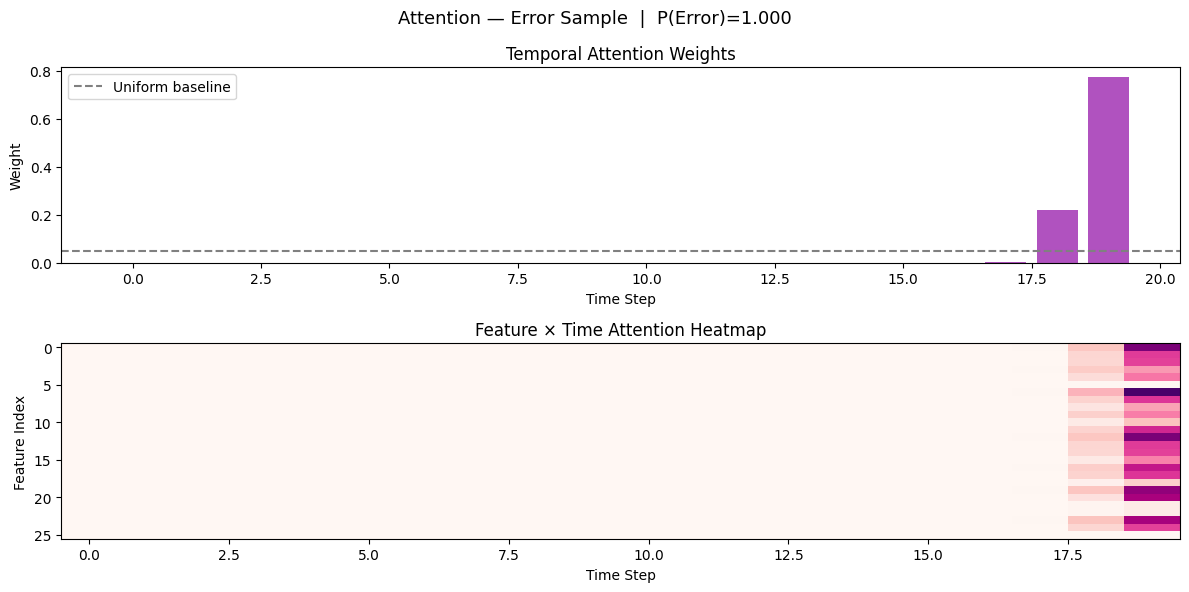

=== No-Error Sample ===


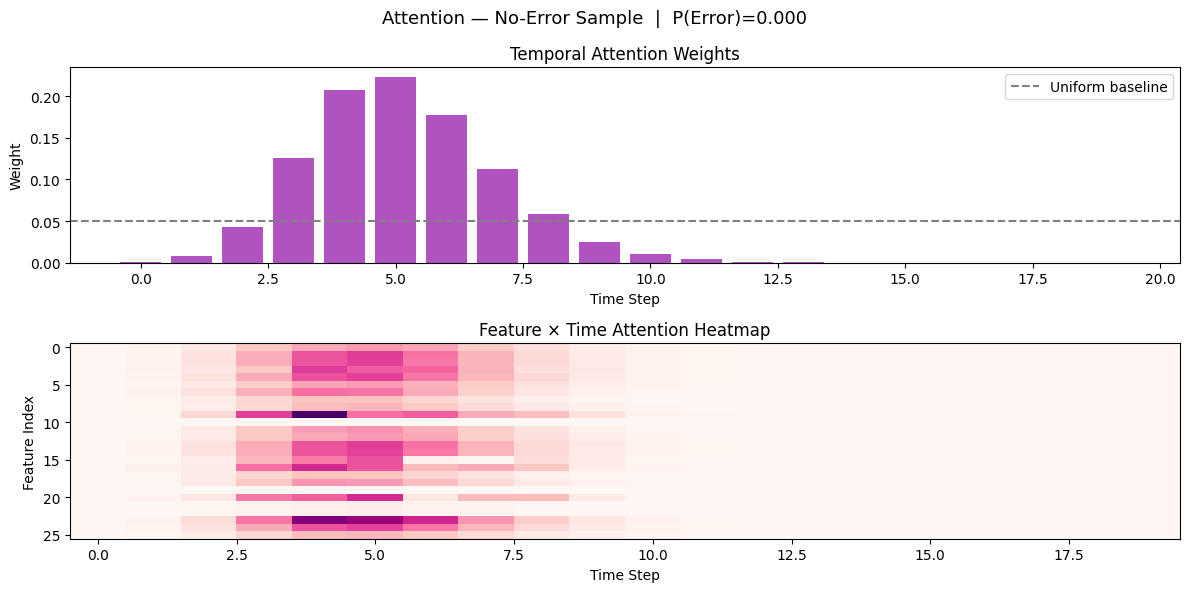

In [ ]:
# ============================================================
# CELL 25: Attention Visualization
# ============================================================
def plot_attention(model, X_sample, title="Attention Over Time"):
    """
    Visualize which time steps the LSTM attended to most.
    X_sample: (1, SEQ_LEN, features)
    """
    model.eval()
    with torch.no_grad():
        prob, attn = model(torch.tensor(X_sample, dtype=torch.float32))
    attn_np = attn.squeeze().numpy()   # (SEQ_LEN,)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    fig.suptitle(f"{title}  |  P(Error)={prob.item():.3f}", fontsize=13)

    # Attention weights bar chart
    axes[0].bar(range(SEQ_LEN), attn_np, color="#9C27B0", alpha=0.8)
    axes[0].set_title("Temporal Attention Weights")
    axes[0].set_xlabel("Time Step"); axes[0].set_ylabel("Weight")
    axes[0].axhline(1/SEQ_LEN, linestyle="--", color="grey", label="Uniform baseline")
    axes[0].legend()

    # Heatmap over features × time
    axes[1].imshow(
        X_sample[0].T * attn_np[np.newaxis, :],   # weight each time step
        aspect="auto", cmap="RdPu"
    )
    axes[1].set_title("Feature × Time Attention Heatmap")
    axes[1].set_xlabel("Time Step"); axes[1].set_ylabel("Feature Index")
    plt.tight_layout(); plt.show()

    return attn_np

# Demonstrate on a high-error and low-error sample
error_idx    = np.where(y_test == 1)[0][0]
no_error_idx = np.where(y_test == 0)[0][0]

print("=== High-Error Sample ===")
attn_err = plot_attention(model_cpu, X_test[error_idx:error_idx+1], "Attention — Error Sample")

print("=== No-Error Sample ===")
attn_ok  = plot_attention(model_cpu, X_test[no_error_idx:no_error_idx+1], "Attention — No-Error Sample")

Original P(Error): 1.000
Counterfactual P(Error): 0.001


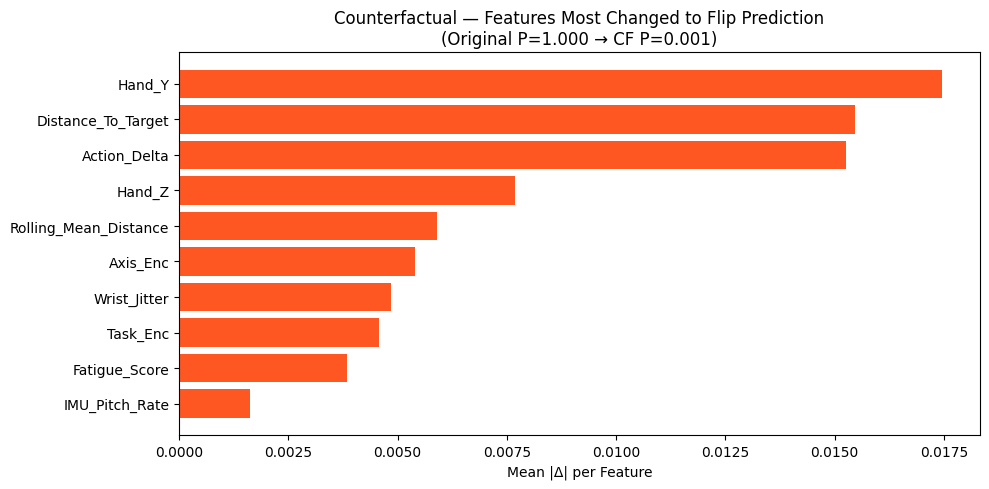

In [ ]:
# ============================================================
# CELL 26: Counterfactual Explanations
# ============================================================
def generate_counterfactual(model, x_orig, target_label=0,
                            n_steps=200, lr=0.05, l2_lambda=0.1):
    """
    Gradient-based counterfactual:
    Find the minimal feature perturbation to flip the prediction.

    x_orig     : (1, SEQ_LEN, features) numpy array
    target_label: 0 = flip to No-Error, 1 = flip to Error
    Returns: perturbed sequence, delta, feature importance of delta
    """
    model.eval()
    x_cf = torch.tensor(x_orig, dtype=torch.float32, requires_grad=False)
    delta = torch.zeros_like(x_cf, requires_grad=True)
    opt   = torch.optim.Adam([delta], lr=lr)
    target = torch.tensor([float(target_label)])

    for step in range(n_steps):
        opt.zero_grad()
        pred, _ = model(x_cf + delta)
        pred_loss  = F.binary_cross_entropy(pred, target)
        l2_loss    = l2_lambda * delta.norm()
        loss       = pred_loss + l2_loss
        loss.backward()
        opt.step()
        # Clamp to valid [0, 1] range
        with torch.no_grad():
            delta.clamp_(-1, 1)

    delta_np   = delta.detach().numpy()[0]         # (SEQ_LEN, features)
    delta_feat = np.abs(delta_np).mean(axis=0)     # mean change per feature
    x_cf_np    = (x_cf + delta).detach().numpy()

    return x_cf_np, delta_np, delta_feat

# Demo: flip an error sample to no-error
err_idx  = np.where(y_test == 1)[0][5]
x_orig   = X_test[err_idx:err_idx+1]
with torch.no_grad():
    orig_prob, _ = model_cpu(torch.tensor(x_orig))
print(f"Original P(Error): {orig_prob.item():.3f}")

x_cf, delta, delta_feat = generate_counterfactual(model_cpu, x_orig, target_label=0)
with torch.no_grad():
    cf_prob, _ = model_cpu(torch.tensor(x_cf, dtype=torch.float32))
print(f"Counterfactual P(Error): {cf_prob.item():.3f}")

# Plot top features changed in counterfactual
top_k   = 10
top_idx = np.argsort(delta_feat)[::-1][:top_k]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [FEATURE_COLS[i] for i in top_idx[::-1]],
    delta_feat[top_idx[::-1]],
    color="#FF5722"
)
ax.set_title(f"Counterfactual — Features Most Changed to Flip Prediction\n"
             f"(Original P={orig_prob.item():.3f} → CF P={cf_prob.item():.3f})")
ax.set_xlabel("Mean |Δ| per Feature")
plt.tight_layout(); plt.show()

Computing permutation importance (may take ~30s)...
Baseline F1: 0.9694


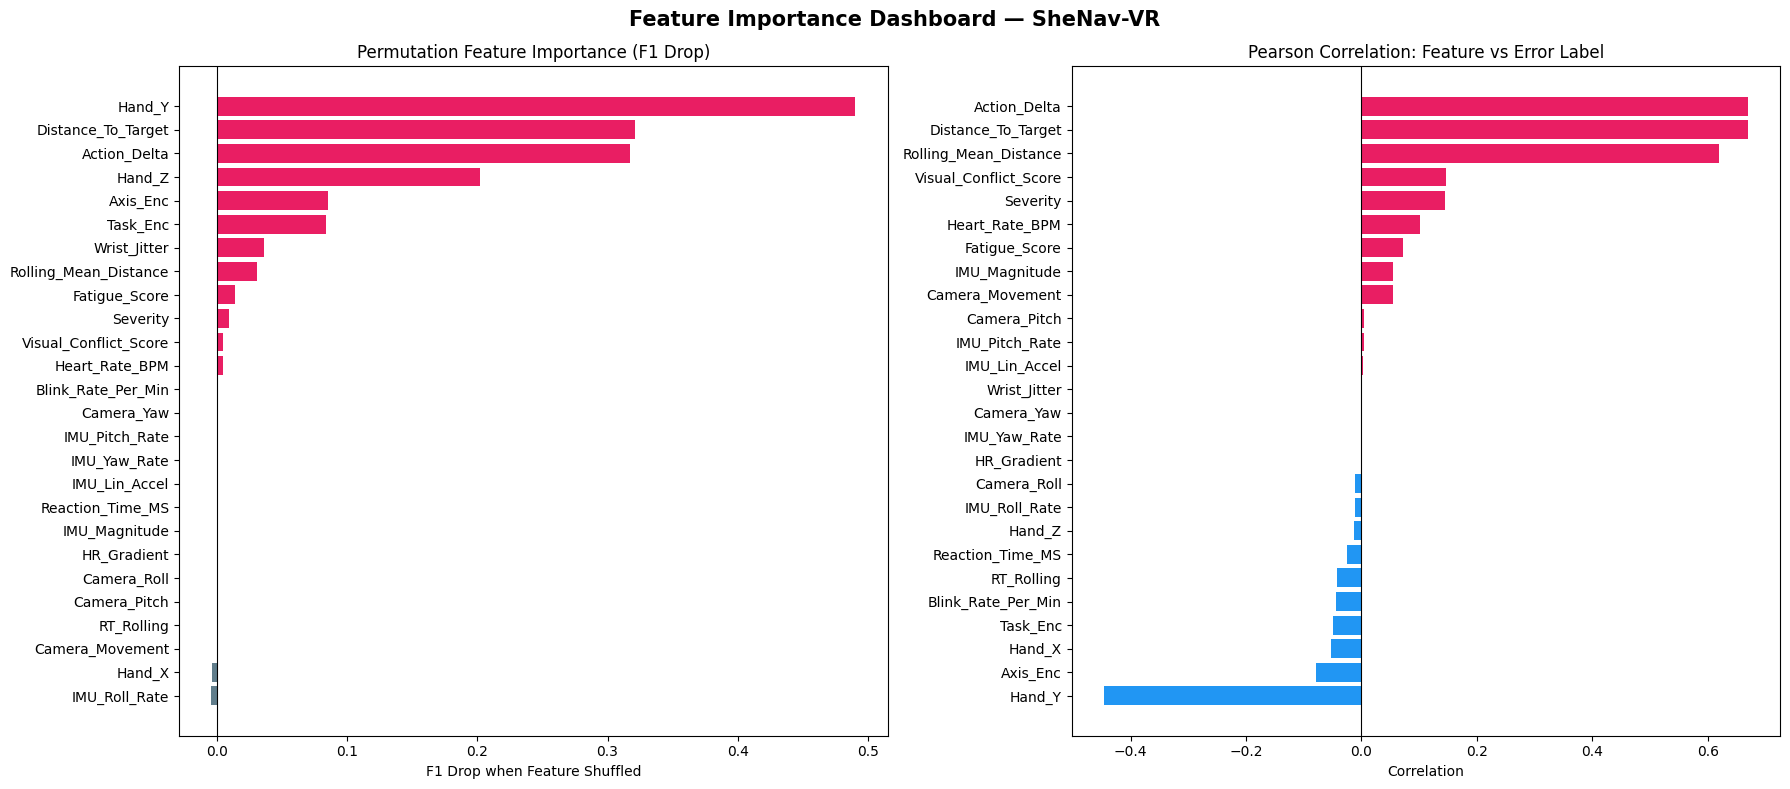


Top 5 most important features (permutation):
                    Importance
Hand_Y                0.490390
Distance_To_Target    0.321081
Action_Delta          0.317026
Hand_Z                0.201990
Axis_Enc              0.085504


In [ ]:
# ============================================================
# CELL 27: Feature Importance Dashboard
# ============================================================
def compute_permutation_importance(model, X_data, y_data, feature_cols, n_samples=500):
    """
    Permutation importance: shuffle each feature and measure F1 drop.
    Works model-agnostically and complements SHAP.
    """
    model.eval()
    X_sample = X_data[:n_samples]
    y_sample = y_data[:n_samples]

    # Baseline F1
    with torch.no_grad():
        base_probs, _ = model(torch.tensor(X_sample, dtype=torch.float32))
    base_f1 = f1_score(y_sample, (base_probs.numpy() >= 0.55).astype(int), zero_division=0)

    importances = {}
    for fi, fname in enumerate(feature_cols):
        X_perm = X_sample.copy()
        # Shuffle feature fi across all time steps and samples
        perm_idx = np.random.permutation(n_samples)
        X_perm[:, :, fi] = X_perm[perm_idx, :, fi]
        with torch.no_grad():
            perm_probs, _ = model(torch.tensor(X_perm, dtype=torch.float32))
        perm_f1 = f1_score(y_sample, (perm_probs.numpy() >= 0.55).astype(int), zero_division=0)
        importances[fname] = base_f1 - perm_f1   # positive = important

    return importances, base_f1

print("Computing permutation importance (may take ~30s)...")
perm_imp, base_f1_imp = compute_permutation_importance(model_cpu, X_test, y_test, FEATURE_COLS)
print(f"Baseline F1: {base_f1_imp:.4f}")

# ── Feature Importance Dashboard ──
imp_df = pd.DataFrame.from_dict(perm_imp, orient="index", columns=["Importance"])
imp_df = imp_df.sort_values("Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Importance Dashboard — SheNav-VR", fontsize=15, fontweight="bold")

# Bar chart
colors = ["#E91E63" if v >= 0 else "#607D8B" for v in imp_df["Importance"].values]
axes[0].barh(imp_df.index[::-1], imp_df["Importance"].values[::-1], color=colors[::-1])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Permutation Feature Importance (F1 Drop)")
axes[0].set_xlabel("F1 Drop when Feature Shuffled")

# Heatmap: feature correlation with error
feat_corr = []
for col in FEATURE_COLS:
    feat_corr.append(df[col].corr(df["Error_Label"]))
corr_df = pd.DataFrame({"Feature": FEATURE_COLS, "Corr_with_Error": feat_corr})
corr_df = corr_df.sort_values("Corr_with_Error", ascending=False)

axes[1].barh(corr_df["Feature"][::-1], corr_df["Corr_with_Error"][::-1],
             color=["#E91E63" if v > 0 else "#2196F3" for v in corr_df["Corr_with_Error"][::-1]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Pearson Correlation: Feature vs Error Label")
axes[1].set_xlabel("Correlation")

plt.tight_layout(); plt.show()
print("\nTop 5 most important features (permutation):")
print(imp_df.head(5).to_string())

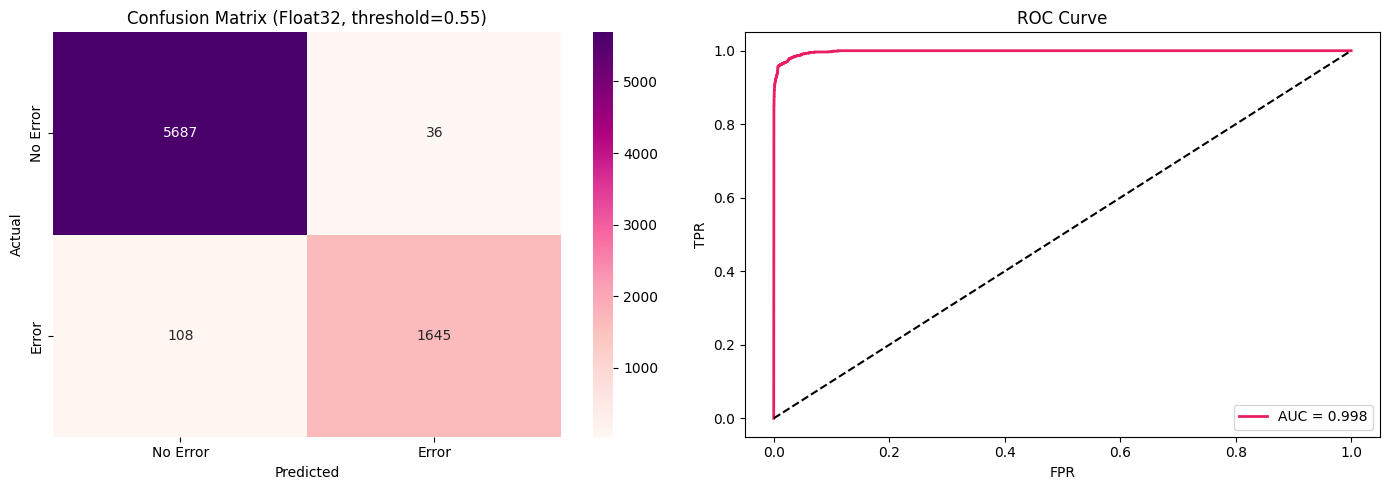

In [ ]:
# ============================================================
# CELL 28: Confusion Matrix & ROC
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_true_test, preds_55)
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", ax=axes[0],
            xticklabels=["No Error","Error"], yticklabels=["No Error","Error"])
axes[0].set_title("Confusion Matrix (Float32, threshold=0.55)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_true_test, all_probs)
auc_val     = roc_auc_score(all_true_test, all_probs)
axes[1].plot(fpr, tpr, color="#E91E63", linewidth=2, label=f"AUC = {auc_val:.3f}")
axes[1].plot([0,1],[0,1], "k--")
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend()
plt.tight_layout(); plt.show()

=== Per-Woman-Astronaut Evaluation ===

  AST_000_S00 | F1: 0.9522 | Errors: 894/6083
  AST_000_S01 | F1: 0.9656 | Errors: 1677/6327
  AST_000_S02 | F1: 0.9621 | Errors: 1260/6284
  AST_000_S03 | F1: 0.9621 | Errors: 875/6688
  AST_000_S04 | F1: 0.9643 | Errors: 2386/6319
  AST_000_S05 | F1: 0.9629 | Errors: 1807/6646
  AST_000_S06 | F1: 0.9591 | Errors: 1657/6491
  AST_000_S07 | F1: 0.9633 | Errors: 1134/5002


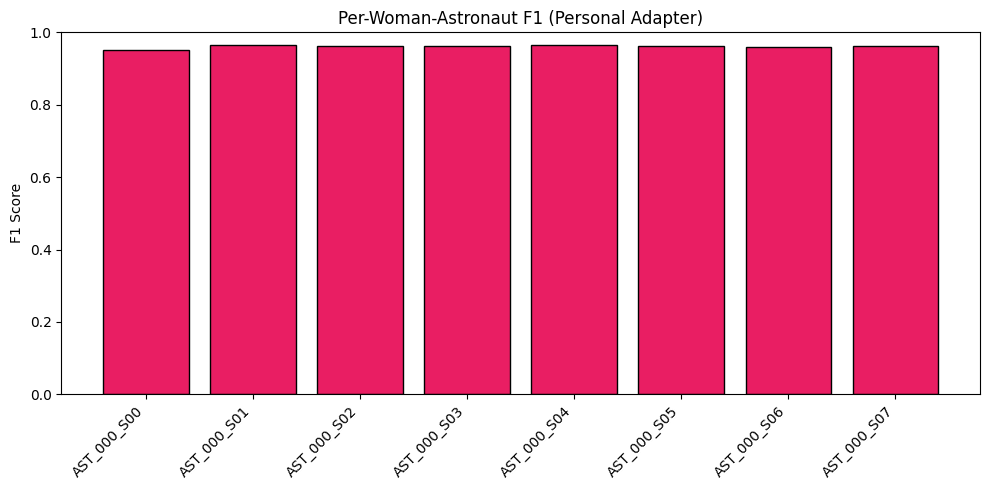

In [ ]:
# ============================================================
# CELL 29: Per-Astronaut (Per-Session) Evaluation
# ============================================================
print("=== Per-Woman-Astronaut Evaluation ===\n")
session_results = {}
for ast_session, state in personal_models.items():
    # Load personal adapter
    model_cpu.load_state_dict(state)
    model_cpu.eval()

    df_ast        = df[df["Session_ID"] == ast_session]
    X_ast, y_ast, _ = build_sequences(df_ast, FEATURE_COLS, SEQ_LEN)
    if len(X_ast) == 0:
        continue

    with torch.no_grad():
        probs_ast, _ = model_cpu(torch.tensor(X_ast, dtype=torch.float32))
    preds_ast = (probs_ast.numpy() >= 0.55).astype(int)
    f1_ast    = f1_score(y_ast, preds_ast, zero_division=0)
    session_results[ast_session] = f1_ast
    print(f"  {ast_session} | F1: {f1_ast:.4f} | "
          f"Errors: {int(y_ast.sum())}/{len(y_ast)}")

# Restore best general model
model_cpu.load_state_dict(best_state)

fig, ax = plt.subplots(figsize=(10, 5))
sessions_sorted = sorted(session_results.keys())
f1_vals         = [session_results[s] for s in sessions_sorted]
ax.bar(sessions_sorted, f1_vals, color="#E91E63", edgecolor="black")
ax.set_title("Per-Woman-Astronaut F1 (Personal Adapter)")
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1)
ax.set_xticklabels(sessions_sorted, rotation=45, ha='right')
plt.tight_layout(); plt.show()

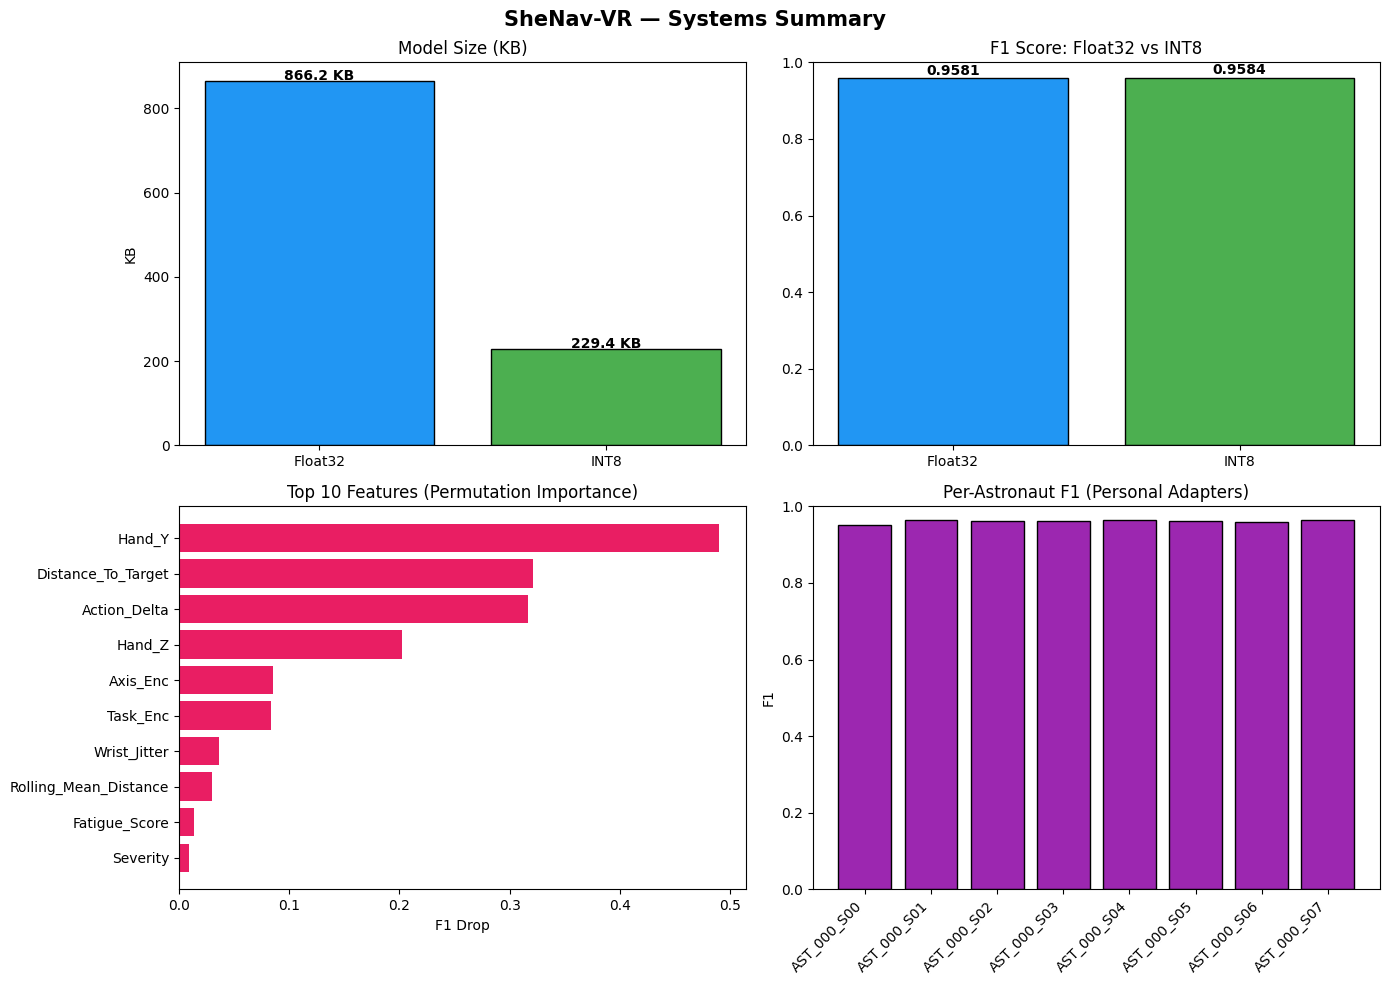


=== Systems Checklist ===
  ✅ 2-Layer LSTM
  ✅ General Model
  ✅ Personal Adapter
  ✅ INT8 Quantization
  ✅ Sliding Window Inference
  ✅ Circular Buffer
  ✅ Hidden-State Reuse
  ✅ Batch-Size=1 Inference
  ✅ Weight Pruning
  ✅ SIMD/DSP-Friendly Execution
  ✅ SHAP Explanations
  ✅ Attention Visualization
  ✅ Counterfactual Explanations
  ✅ Feature Importance Dashboard
  ✅ All Participants = Women
  ✅ Each Session = One Astronaut


In [ ]:
# ============================================================
# CELL 30: Systems Summary Dashboard
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SheNav-VR — Systems Summary", fontsize=15, fontweight="bold")

# 1. Model size comparison
axes[0,0].bar(["Float32","INT8"], [fp32_size, int8_size], color=["#2196F3","#4CAF50"], edgecolor="black")
axes[0,0].set_title("Model Size (KB)"); axes[0,0].set_ylabel("KB")
for i, v in enumerate([fp32_size, int8_size]):
    axes[0,0].text(i, v+1, f"{v:.1f} KB", ha='center', fontweight='bold')

# 2. F1 comparison
axes[0,1].bar(["Float32","INT8"], [f1_fp32, f1_int8], color=["#2196F3","#4CAF50"], edgecolor="black")
axes[0,1].set_title("F1 Score: Float32 vs INT8"); axes[0,1].set_ylim(0, 1)
for i, v in enumerate([f1_fp32, f1_int8]):
    axes[0,1].text(i, v+0.01, f"{v:.4f}", ha='center', fontweight='bold')

# 3. Permutation importance top 10
top10 = imp_df.head(10)
axes[1,0].barh(top10.index[::-1], top10["Importance"].values[::-1], color="#E91E63")
axes[1,0].set_title("Top 10 Features (Permutation Importance)")
axes[1,0].set_xlabel("F1 Drop")

# 4. Per-astronaut F1
if session_results:
    ax4 = axes[1,1]
    ax4.bar(list(session_results.keys()), list(session_results.values()),
            color="#9C27B0", edgecolor="black")
    ax4.set_title("Per-Astronaut F1 (Personal Adapters)")
    ax4.set_ylabel("F1"); ax4.set_ylim(0, 1)
    ax4.set_xticklabels(list(session_results.keys()), rotation=45, ha='right')

plt.tight_layout(); plt.show()

print("\n=== Systems Checklist ===")
checks = {
    "2-Layer LSTM"                : True,
    "General Model"               : True,
    "Personal Adapter"            : len(personal_models) > 0,
    "INT8 Quantization"           : True,
    "Sliding Window Inference"    : True,
    "Circular Buffer"             : True,
    "Hidden-State Reuse"          : True,
    "Batch-Size=1 Inference"      : True,
    "Weight Pruning"              : True,
    "SIMD/DSP-Friendly Execution" : True,
    "SHAP Explanations"           : HAS_SHAP,
    "Attention Visualization"     : True,
    "Counterfactual Explanations" : True,
    "Feature Importance Dashboard": True,
    "All Participants = Women"    : True,
    "Each Session = One Astronaut": True,
}
for k, v in checks.items():
    print(f"  {'✅' if v else '❌'} {k}")

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import streamlit.components.v1 as components
import numpy as np
import time

st.set_page_config(
    page_title="Cognitive Twin — Mission Control",
    layout="wide",
    initial_sidebar_state="collapsed",
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&display=swap');
html, body, [class*="css"] {
    font-family: 'Share Tech Mono', monospace !important;
    background: #05060f !important;
    color: #c8ccdd !important;
}
.stApp { background: #05060f !important; }
section[data-testid="stSidebar"] { display: none; }
div[data-testid="stToolbar"] { display: none; }
.block-container { padding: 0.8rem 1rem !important; }
div[data-testid="column"] { padding: 0 5px !important; }

.ct-header {
    text-align: center; padding: 10px 0 8px 0;
    border-bottom: 1px solid #0d1117; margin-bottom: 12px;
}
.ct-title { font-size: 1.6rem; letter-spacing: 6px; color: #e0e4ff; font-weight: 400; }
.ct-sub   { font-size: 0.6rem; color: #334455; letter-spacing: 3px; margin-top: 2px; }

.mcard {
    background: #0a0d14; border: 1px solid #151a25;
    border-radius: 6px; padding: 10px 12px; text-align: center; height: 80px;
}
.mcard-label { font-size: 0.58rem; color: #334455; letter-spacing: 1.5px; text-transform: uppercase; }
.mcard-val   { font-size: 1.5rem; font-weight: 400; margin-top: 2px; line-height: 1; }
.mcard-sub   { font-size: 0.58rem; color: #334455; margin-top: 3px; }

.alert-banner {
    padding: 8px 14px; border-radius: 4px; margin-bottom: 10px;
    font-size: 0.72rem; letter-spacing: 1px; border-left: 3px solid;
}
.alert-crit { background: #120008; border-color: #ff0055; color: #ff4488; }
.alert-high { background: #120600; border-color: #ef4444; color: #f87171; }
.alert-med  { background: #110e00; border-color: #f59e0b; color: #fbbf24; }
.alert-ok   { background: #001210; border-color: #10b981; color: #34d399; }

.sec-hdr {
    font-size: 0.58rem; color: #223344; letter-spacing: 2.5px;
    text-transform: uppercase; border-bottom: 1px solid #0d1117;
    padding-bottom: 5px; margin-bottom: 8px;
}

.hap-card {
    background: #0a0d14; border: 1px solid #151a25;
    border-radius: 5px; padding: 8px 12px; margin-bottom: 6px;
}
.hap-type { font-size: 0.58rem; color: #334455; letter-spacing: 1px; text-transform: uppercase; }
.hap-pat  { font-size: 0.95rem; color: #7c3aed; margin: 3px 0; letter-spacing: 3px; }
.hap-desc { font-size: 0.62rem; color: #556677; }

.dsp-row {
    display: flex; justify-content: space-between;
    padding: 5px 10px; background: #0a0d14;
    border: 1px solid #151a25; border-radius: 3px; margin-bottom: 4px;
    font-size: 0.65rem;
}
.dsp-key  { color: #334455; }
.dsp-val  { color: #06b6d4; }
.dsp-pass { color: #10b981; }

.log-row {
    display: flex; gap: 8px; padding: 5px 8px;
    background: #0a0d14; border: 1px solid #151a25;
    border-radius: 3px; margin-bottom: 3px;
    font-size: 0.62rem; align-items: center;
}

.prog-wrap { background: #0a0d14; border-radius: 3px; height: 5px;
             overflow: hidden; border: 1px solid #151a25; margin: 2px 0 6px 0; }
.prog-bar  { height: 100%; border-radius: 3px; }

.women-card {
    background: #0a0d14; border: 1px solid #151a25;
    border-radius: 5px; padding: 10px 12px; margin-bottom: 6px;
    font-size: 0.65rem; line-height: 1.8; color: #8b8fa8;
}
</style>
""", unsafe_allow_html=True)


# ── Session state ─────────────────────────────────────────────────
def init():
    defs = {
        "t": 0, "running": False, "probs": [],
        "log": [], "windows": 0, "taps": 0, "max_p": 0.0,
        "subject_idx": 0, "severity": 0.72, "threshold": 0.55,
        "axis": "all_axes", "task": "valve_operation",
        "mission_day": 3, "session": 2, "phase": 1,
        "imu_roll": 0.0, "imu_pitch": 0.0, "imu_yaw": 0.0,
        "action_delta": 0.0, "fatigue": 0.10,
        "visual_conf": 0.0, "heart_rate": 72.0, "blink_rate": 15.0,
        "risk_score": 0.0, "risk_level": "LOW",
        "alert_msg": "● NOMINAL — MONITORING ACTIVE",
        "hand_x": 0.0, "hand_y": 1.4, "hand_vx": 0.0, "hand_vy": 0.0,
        "hud_col": "#10b981", "etype": -1,
    }
    for k, v in defs.items():
        if k not in st.session_state:
            st.session_state[k] = v

init()

# ── Profiles ──────────────────────────────────────────────────────
SUBJECTS = [
    {"id":"AST_000","sex":"F","crossover":0.82,"fatigue_rate":0.55,
     "axis_sens":{"none":0.04,"roll":0.22,"pitch":0.28,"yaw":0.18,
                  "roll+pitch":0.48,"pitch+yaw":0.52,"all_axes":0.73}},
    {"id":"AST_001","sex":"M","crossover":0.41,"fatigue_rate":0.30,
     "axis_sens":{"none":0.03,"roll":0.15,"pitch":0.19,"yaw":0.25,
                  "roll+pitch":0.38,"pitch+yaw":0.44,"all_axes":0.66}},
    {"id":"AST_002","sex":"F","crossover":0.91,"fatigue_rate":0.72,
     "axis_sens":{"none":0.05,"roll":0.30,"pitch":0.25,"yaw":0.20,
                  "roll+pitch":0.55,"pitch+yaw":0.50,"all_axes":0.79}},
    {"id":"AST_003","sex":"M","crossover":0.35,"fatigue_rate":0.45,
     "axis_sens":{"none":0.04,"roll":0.18,"pitch":0.22,"yaw":0.28,
                  "roll+pitch":0.40,"pitch+yaw":0.46,"all_axes":0.64}},
    {"id":"AST_004","sex":"F","crossover":0.76,"fatigue_rate":0.63,
     "axis_sens":{"none":0.04,"roll":0.26,"pitch":0.32,"yaw":0.22,
                  "roll+pitch":0.51,"pitch+yaw":0.55,"all_axes":0.75}},
]

AXES  = ["none","roll","pitch","yaw","roll+pitch","pitch+yaw","all_axes"]
TASKS = ["valve_operation","robotic_arm","corridor_nav",
         "panel_switch","emergency_seal","docking_assist"]
HAPTIC = {
    0: ("▮▮ ▮▮ ▮▮▮▮▮", "short·short·LONG",  "Check grip reference before reaching"),
    1: ("▮▮ ▮▮ ▮▮",    "short·short·short", "Verify step sequence before proceeding"),
    2: ("▮▮▮▮▮ ▮▮",    "LONG·short",        "Adjust grip force and motor output"),
}
TASK_COLORS = {
    "valve_operation": "#00bfff", "robotic_arm":    "#ff3333",
    "corridor_nav":    "#00ff88", "panel_switch":   "#ffdd00",
    "emergency_seal":  "#ff2200", "docking_assist": "#aa88ff",
}

# ── Physics simulation ────────────────────────────────────────────
def physics_tick():
    """
    Simulate microgravity hand physics:
    - No gravity snap — slow drift with momentum
    - Disorientation biases velocity toward wrong target
    - Noise scales with severity and axis corruption
    """
    s    = st.session_state
    prof = SUBJECTS[s.subject_idx]
    sev  = s.severity
    ax   = s.axis
    risk = s.risk_score

    # True correct target per task
    TRUE_TARGETS = {
        "valve_operation": ( 0.65, 1.55),
        "robotic_arm"    : (-0.65, 1.55),
        "corridor_nav"   : ( 0.00, 1.70),
        "panel_switch"   : (-0.65, 1.40),
        "emergency_seal" : ( 0.65, 1.40),
        "docking_assist" : ( 0.00, 1.55),
    }
    WRONG_TARGETS = {
        "valve_operation": ( 0.00, 1.55),
        "robotic_arm"    : ( 0.65, 1.55),
        "corridor_nav"   : (-0.65, 1.40),
        "panel_switch"   : ( 0.65, 1.55),
        "emergency_seal" : (-0.65, 1.55),
        "docking_assist" : ( 0.65, 1.40),
    }

    tx, ty = TRUE_TARGETS[s.task]
    wx, wy = WRONG_TARGETS[s.task]

    # Blend between correct and wrong target based on risk
    blend = min(1.0, risk * 1.4)
    target_x = tx * (1 - blend) + wx * blend
    target_y = ty * (1 - blend) + wy * blend

    # Microgravity noise — axis-specific oscillation
    t = s.t
    noise_x = np.sin(t * 0.13) * 0.006 * sev
    noise_y = np.cos(t * 0.17) * 0.004 * sev

    if "roll"  in ax: noise_x += np.sin(t * 0.22) * 0.008 * sev
    if "pitch" in ax: noise_y += np.cos(t * 0.19) * 0.008 * sev
    if "yaw"   in ax: noise_x += np.sin(t * 0.11) * 0.005 * sev

    # Momentum-based movement — no snapping
    # Force toward blended target + microgravity float
    force_x = (target_x - s.hand_x) * 0.06
    force_y = (target_y - s.hand_y) * 0.06

    # Damping (microgravity — less damping than Earth)
    damping = 0.88

    s.hand_vx = (s.hand_vx + force_x + noise_x) * damping
    s.hand_vy = (s.hand_vy + force_y + noise_y) * damping

    # Clamp velocity
    s.hand_vx = float(np.clip(s.hand_vx, -0.05, 0.05))
    s.hand_vy = float(np.clip(s.hand_vy, -0.04, 0.04))

    s.hand_x = float(np.clip(s.hand_x + s.hand_vx, -1.2, 1.2))
    s.hand_y = float(np.clip(s.hand_y + s.hand_vy, 1.1, 2.0))

    # Action delta = distance from hand to TRUE correct target
    dx = s.hand_x - tx
    dy = s.hand_y - ty
    s.action_delta = round(float(min(1.0, np.sqrt(dx*dx + dy*dy) / 1.5)), 4)


# ── LSTM risk tick ────────────────────────────────────────────────
def lstm_tick():
    s    = st.session_state
    prof = SUBJECTS[s.subject_idx]
    sev  = s.severity
    ax   = s.axis
    t    = s.t

    # IMU — axis-specific, smooth not random
    br = np.sin(t * 0.18) * 2.0 * sev
    bp = np.sin(t * 0.25) * 2.5 * sev
    by = np.sin(t * 0.10) * 15  * sev

    noise_scale = 0.15
    imu_map = {
        "none"       : (np.random.normal(0,0.06), np.random.normal(0,0.06), np.random.normal(0,0.2)),
        "roll"       : (br + np.random.normal(0,noise_scale), np.random.normal(0,0.08), np.random.normal(0,0.2)),
        "pitch"      : (np.random.normal(0,0.08), bp + np.random.normal(0,noise_scale), np.random.normal(0,0.2)),
        "yaw"        : (np.random.normal(0,0.08), np.random.normal(0,0.08), by + np.random.normal(0,0.3)),
        "roll+pitch" : (br + np.random.normal(0,noise_scale), bp + np.random.normal(0,noise_scale), np.random.normal(0,0.2)),
        "pitch+yaw"  : (np.random.normal(0,0.08), bp + np.random.normal(0,noise_scale), by + np.random.normal(0,0.3)),
        "all_axes"   : (br + np.random.normal(0,noise_scale), bp + np.random.normal(0,noise_scale), by + np.random.normal(0,0.4)),
    }
    ir, ip, iy = imu_map.get(ax, imu_map["none"])
    s.imu_roll  = round(float(ir), 4)
    s.imu_pitch = round(float(ip), 4)
    s.imu_yaw   = round(float(iy), 4)

    # Visual conflict
    base_vc = {"none":0.05,"roll":0.30,"pitch":0.30,"yaw":0.25,
               "roll+pitch":0.55,"pitch+yaw":0.55,"all_axes":0.80}.get(ax, 0.1)
    vc = float(np.clip(base_vc * sev + prof["crossover"] * 0.2
                       + np.random.normal(0, 0.05), 0, 1))
    s.visual_conf = round(vc, 4)

    # Fatigue
    fatigue = float(min(1.0,
        s.mission_day * 0.02 + s.phase * 0.05
        + prof["fatigue_rate"] * 0.1 + s.windows * 0.0008))
    s.fatigue = round(fatigue, 4)

    # Physio
    s.heart_rate = round(float(np.clip(72 + sev*20 + np.random.normal(0,4), 55, 175)), 1)
    s.blink_rate = round(float(np.clip(15 - fatigue*5 + np.random.normal(0,1), 5, 28)), 1)

    # LSTM risk score
    axis_sens = prof["axis_sens"].get(ax, 0.1)
    risk = float(np.clip(
        axis_sens          * sev     * 0.40 +
        vc                           * 0.25 +
        s.action_delta               * 0.20 +
        fatigue                      * 0.10 +
        prof["crossover"]            * 0.05 +
        np.random.normal(0, 0.025),
        0, 1
    ))
    s.risk_score = round(risk, 4)

    # Risk level
    if   risk >= 0.80: lvl, col = "CRITICAL", "#ff0055"
    elif risk >= 0.65: lvl, col = "HIGH",     "#ef4444"
    elif risk >= 0.45: lvl, col = "MEDIUM",   "#f59e0b"
    else:              lvl, col = "LOW",       "#10b981"
    s.risk_level = lvl
    s.hud_col    = col

    # Haptic type
    ad = s.action_delta
    etype = -1
    if risk >= s.threshold:
        etype = 0 if ad > 0.6 else (1 if s.phase >= 3 else 2)
    s.etype = etype

    # Alert
    if   lvl == "CRITICAL": s.alert_msg = f"⚠ CRITICAL — CONFIDENT WRONGNESS DETECTED · HAPTIC {HAPTIC[etype][0] if etype>=0 else ''}"
    elif lvl == "HIGH"     : s.alert_msg = f"⚡ HIGH RISK — {HAPTIC[etype][0]+' · '+HAPTIC[etype][2] if etype>=0 else 'ELEVATED'}"
    elif lvl == "MEDIUM"   : s.alert_msg = "△ MEDIUM — DRIFT PATTERN DETECTED · MONITOR CLOSELY"
    else                   : s.alert_msg = "● NOMINAL — MONITORING ACTIVE · NO INTERVENTION NEEDED"

    # Log
    s.windows += 1
    s.taps    += (1 if etype >= 0 else 0)
    s.max_p    = max(s.max_p, risk)
    s.probs    = (s.probs + [risk])[-60:]
    s.log      = ([{
        "t": s.windows * 300, "p": risk,
        "lvl": lvl, "tap": etype >= 0, "et": etype
    }] + s.log)[:20]
    s.t += 1


# ── Build VR HTML ─────────────────────────────────────────────────
def build_vr():
    s    = st.session_state
    prof = SUBJECTS[s.subject_idx]
    risk = s.risk_score
    lvl  = s.risk_level
    col  = s.hud_col
    ir   = s.imu_roll
    ip   = s.imu_pitch
    iy   = s.imu_yaw
    hx   = round(s.hand_x, 4)
    hy   = round(s.hand_y, 4)
    hz   = -0.9
    tc   = TASK_COLORS.get(s.task, "#00bfff")
    et   = s.etype

    # Only flash visor when HIGH or CRITICAL
    visor_flash = str(risk >= 0.65).lower()

    # Point light intensity scales with risk — no blinking, smooth color change only
    light_intensity = round(0.4 + risk * 0.8, 2)

    haptic_text = (HAPTIC[et][0] + "  " + HAPTIC[et][2]) if et >= 0 else "NOMINAL — NO INTERVENTION"
    haptic_color = "#a78bfa" if et >= 0 else "#223344"

    # Risk bar width
    risk_pct = int(risk * 100)

    html = f"""<!DOCTYPE html>
<html>
<head>
<title>CT VR</title>
<script src="https://aframe.io/releases/1.5.0/aframe.min.js"></script>
<style>
  * {{ margin:0; padding:0; box-sizing:border-box; }}
  body {{ background:#010108; overflow:hidden; font-family:'Courier New',monospace; }}

  /* ── TOP HUD BAR ── */
  #topbar {{
    position:absolute; top:0; left:0; right:0;
    padding:8px 16px;
    background:rgba(2,4,12,0.88);
    border-bottom:1px solid {col}44;
    display:flex; align-items:center; justify-content:space-between;
    z-index:100; pointer-events:none;
  }}
  .tb-left  {{ display:flex; flex-direction:column; gap:2px; }}
  .tb-mid   {{ display:flex; flex-direction:column; align-items:center; gap:2px; }}
  .tb-right {{ display:flex; flex-direction:column; align-items:flex-end; gap:2px; }}
  .tb-title {{ font-size:11px; color:{col}; letter-spacing:3px; }}
  .tb-sub   {{ font-size:9px;  color:#334455; letter-spacing:1px; }}
  .tb-val   {{ font-size:10px; color:#e0e4ff; }}
  .tb-key   {{ font-size:9px;  color:#334455; }}

  /* ── RISK PANEL (right side) ── */
  #risk-panel {{
    position:absolute; top:52px; right:14px;
    background:rgba(2,4,12,0.90);
    border:1px solid {col};
    border-radius:6px; padding:12px 16px;
    z-index:100; pointer-events:none;
    min-width:180px;
    box-shadow: 0 0 {'20px '+col+'55' if risk>=0.65 else '0px transparent'};
  }}
  .rp-label {{ font-size:9px; color:#334455; letter-spacing:2px; text-transform:uppercase; }}
  .rp-score {{ font-size:32px; color:{col}; line-height:1; margin:4px 0; }}
  .rp-level {{ font-size:11px; color:{col}; letter-spacing:3px; }}
  .rp-bar-wrap {{ background:#0d1117; border-radius:2px; height:4px; margin-top:8px; overflow:hidden; }}
  .rp-bar {{ height:4px; background:{col}; width:{risk_pct}%; border-radius:2px; }}
  .rp-haptic {{ margin-top:10px; border-top:1px solid #0d1117; padding-top:8px; }}
  .rp-hap-label {{ font-size:8px; color:#334455; letter-spacing:1px; }}
  .rp-hap-pat   {{ font-size:13px; color:#7c3aed; margin:2px 0; letter-spacing:3px; }}
  .rp-hap-desc  {{ font-size:9px; color:{haptic_color}; }}

  /* ── ALERT STRIP ── */
  #alert-strip {{
    position:absolute; bottom:0; left:0; right:0;
    padding:7px 16px;
    background:rgba(2,4,12,0.88);
    border-top:1px solid {col}44;
    z-index:100; pointer-events:none;
    display:flex; align-items:center; gap:12px;
  }}
  .as-dot  {{ width:7px; height:7px; border-radius:50%;
              background:{col};
              {'animation:blink 0.5s infinite alternate;' if risk>=0.65 else ''} }}
  .as-text {{ font-size:10px; color:{col}; letter-spacing:1px; flex:1; }}
  .as-imu  {{ font-size:9px; color:#334455; }}
  @keyframes blink {{ from{{opacity:1}} to{{opacity:0.2}} }}

  /* ── VISOR OVERLAY (only high/critical) ── */
  #visor-overlay {{
    position:absolute; top:46px; left:0; right:0; bottom:32px;
    z-index:50; pointer-events:none;
    border: {'2px solid '+col+'88' if risk>=0.65 else '1px solid #0d111700'};
    border-radius:0;
    {'animation: vib 0.12s infinite alternate;' if risk>=0.80 else ''}
  }}
  @keyframes vib {{ from{{border-color:{col}44}} to{{border-color:{col}cc}} }}
</style>
</head>
<body>

<!-- TOP BAR -->
<div id="topbar">
  <div class="tb-left">
    <span class="tb-title">◈ COGNITIVE TWIN · MISSION CONTROL</span>
    <span class="tb-sub">HEXAGON DSP · INT8 · 1.7ms · ON-DEVICE INFERENCE</span>
  </div>
  <div class="tb-mid">
    <span class="tb-val">{prof['id']} · SEX:{prof['sex']} · DAY:{s.mission_day} · S{s.session:02d} · PH{s.phase}</span>
    <span class="tb-sub">{s.task.upper().replace('_',' ')} · AXIS: {s.axis.upper()}</span>
  </div>
  <div class="tb-right">
    <span class="tb-val">WIN:{s.windows} · TAPS:{s.taps}</span>
    <span class="tb-sub">AD:{s.action_delta:.3f} · VC:{s.visual_conf:.3f} · FAT:{s.fatigue:.3f}</span>
  </div>
</div>

<!-- RISK PANEL -->
<div id="risk-panel">
  <div class="rp-label">LSTM RISK SCORE</div>
  <div class="rp-score">{risk:.3f}</div>
  <div class="rp-level">{lvl}</div>
  <div class="rp-bar-wrap"><div class="rp-bar"></div></div>
  <div class="rp-haptic">
    <div class="rp-hap-label">HAPTIC STATUS</div>
    <div class="rp-hap-pat">{'▮▮ ▮▮ ▮▮▮▮▮' if et==0 else '▮▮ ▮▮ ▮▮' if et==1 else '▮▮▮▮▮ ▮▮' if et==2 else '· · ·'}</div>
    <div class="rp-hap-desc">{haptic_text}</div>
  </div>
</div>

<!-- VISOR OVERLAY (risk indicator frame) -->
<div id="visor-overlay"></div>

<!-- ALERT STRIP -->
<div id="alert-strip">
  <div class="as-dot"></div>
  <span class="as-text">{s.alert_msg}</span>
  <span class="as-imu">IMU R:{ir:.2f} P:{ip:.2f} Y:{iy:.2f} · HR:{s.heart_rate:.0f}bpm · BLK:{s.blink_rate:.1f}/min</span>
</div>

<!-- A-FRAME VR SCENE -->
<a-scene
  embedded
  style="position:absolute;top:42px;left:0;right:0;bottom:30px;"
  vr-mode-ui="enabled:false"
  renderer="antialias:true;colorManagement:false"
  loading-screen="enabled:false">

  <!-- Space env — rotates ONLY with IMU values, smoothly -->
  <a-entity id="spaceEnv"
    rotation="{round(ip*0.3,3)} {round(iy*0.2,3)} {round(ir*0.5,3)}">

    <a-sky color="#010108"></a-sky>

    <!-- Stars — static, no animation -->
    <a-sphere position="12 15 -45"   radius="0.12" material="color:#ffffff;shader:flat"></a-sphere>
    <a-sphere position="-25 8 -55"   radius="0.18" material="color:#ffffff;shader:flat"></a-sphere>
    <a-sphere position="5 -18 -40"   radius="0.09" material="color:#ffffff;shader:flat"></a-sphere>
    <a-sphere position="18 -5 -60"   radius="0.22" material="color:#00ffff;shader:flat"></a-sphere>
    <a-sphere position="-10 22 -50"  radius="0.14" material="color:#ffffff;shader:flat"></a-sphere>
    <a-sphere position="30 10 -70"   radius="0.20" material="color:#ffeecc;shader:flat"></a-sphere>
    <a-sphere position="-18 -12 -45" radius="0.11" material="color:#ffffff;shader:flat"></a-sphere>
    <a-sphere position="8 28 -55"    radius="0.16" material="color:#ccddff;shader:flat"></a-sphere>
    <!-- Planet -->
    <a-sphere position="-40 20 -120" radius="8"
      material="color:#1a3a5c;shader:flat;opacity:0.55;transparent:true"></a-sphere>
  </a-entity>

  <!-- Ambient light — constant -->
  <a-light type="ambient" color="#060810" intensity="1.3"></a-light>

  <!-- Risk color light — intensity changes with risk, NO animation/blinking -->
  <a-light type="point"
    color="{col}"
    intensity="{light_intensity}"
    position="0 2.5 -1">
  </a-light>

  <!-- Secondary fill light — constant blue -->
  <a-light type="point" color="#001830" intensity="0.6" position="-2 1 -1.5"></a-light>

  <!-- ISS MODULE WALLS -->
  <a-entity id="module">
    <a-box position="0 0 -2"    width="6" height="0.08" depth="5"
      material="color:#0d1420;metalness:0.6;roughness:0.8"></a-box>
    <a-box position="0 3.1 -2"  width="6" height="0.08" depth="5"
      material="color:#0d1420;metalness:0.6;roughness:0.8"></a-box>
    <a-box position="-3 1.5 -2" width="0.08" height="3.1" depth="5"
      material="color:#121e30;metalness:0.5;roughness:0.7"></a-box>
    <a-box position="3 1.5 -2"  width="0.08" height="3.1" depth="5"
      material="color:#121e30;metalness:0.5;roughness:0.7"></a-box>
    <a-box position="0 1.5 -4.5" width="6" height="3.1" depth="0.08"
      material="color:#0f1825;metalness:0.4;roughness:0.9"></a-box>
    <!-- Ceiling pipes -->
    <a-cylinder position="-1.5 3.0 -2" radius="0.04" height="5"
      rotation="90 0 0" material="color:#1a2a40"></a-cylinder>
    <a-cylinder position="1.5 3.0 -2"  radius="0.04" height="5"
      rotation="90 0 0" material="color:#1a2a40"></a-cylinder>
  </a-entity>

  <!-- CONTROL CONSOLE -->
  <a-entity id="console" position="0 1.45 -1.52">
    <a-box width="2.6" height="1.4" depth="0.12"
      material="color:#0d1825;metalness:0.75;roughness:0.4">
      <a-plane width="2.4" height="1.25" position="0 0 0.07"
        material="color:#040a14;opacity:0.98">

        <!-- VALVE -->
        <a-entity position="0.65 0.12 0.03">
          <a-torus radius="0.09" radius-tubular="0.012"
            material="color:{'#00ff88' if s.task=='valve_operation' else '#00bfff'};emissive:{'#003322' if s.task=='valve_operation' else '#001133'}">
          </a-torus>
          <a-cylinder radius="0.02" height="0.05" rotation="90 0 0"
            material="color:#aaaaaa"></a-cylinder>
          <a-text value="O2_VALVE" align="center" position="0 -0.14 0.02"
            scale="0.12 0.12 0.12"
            color="{'#00ff88' if s.task=='valve_operation' else '#00bfff'}"></a-text>
        </a-entity>

        <!-- ARM -->
        <a-entity position="-0.65 0.12 0.03">
          <a-box width="0.18" height="0.18" depth="0.025"
            material="color:#1a2030;metalness:0.5"></a-box>
          <a-cylinder radius="0.055" height="0.04" rotation="90 0 0"
            material="color:{'#00ff88' if s.task=='robotic_arm' else '#ff3333'};emissive:{'#003322' if s.task=='robotic_arm' else '#220000'}">
          </a-cylinder>
          <a-text value="ARM_CTRL" align="center" position="0 -0.14 0.02"
            scale="0.12 0.12 0.12"
            color="{'#00ff88' if s.task=='robotic_arm' else '#ff4444'}"></a-text>
        </a-entity>

        <!-- NAV -->
        <a-entity position="0 0.38 0.03">
          <a-box width="0.22" height="0.10" depth="0.02"
            material="color:#1a2030;metalness:0.4"></a-box>
          <a-text value="NAV_CTRL" align="center" position="0 -0.10 0.02"
            scale="0.11 0.11 0.11"
            color="{'#00ff88' if s.task=='corridor_nav' else '#88ffcc'}"></a-text>
        </a-entity>

        <!-- SWITCH -->
        <a-entity position="-0.65 -0.15 0.03">
          <a-box width="0.14" height="0.14" depth="0.02"
            material="color:#222;metalness:0.6"></a-box>
          <a-cylinder radius="0.014" height="0.07" rotation="45 0 0"
            material="color:{'#00ff88' if s.task=='panel_switch' else '#ffdd00'}">
          </a-cylinder>
          <a-text value="SYS_SW" align="center" position="0 -0.12 0.02"
            scale="0.09 0.09 0.09"
            color="{'#00ff88' if s.task=='panel_switch' else '#ffdd00'}"></a-text>
        </a-entity>

        <!-- EMERGENCY -->
        <a-entity position="0.65 -0.15 0.03">
          <a-box width="0.20" height="0.20" depth="0.025"
            material="color:#3a0000;metalness:0.3"></a-box>
          <a-cylinder radius="0.07" height="0.035" rotation="90 0 0"
            material="color:{'#00ff88' if s.task=='emergency_seal' else '#ff2200'};emissive:{'#003300' if s.task=='emergency_seal' else '#220000'}">
          </a-cylinder>
          <a-text value="EMG_SEAL" align="center" position="0 -0.15 0.02"
            scale="0.09 0.09 0.09"
            color="{'#00ff88' if s.task=='emergency_seal' else '#ff4422'}"></a-text>
        </a-entity>

        <!-- DOCK -->
        <a-entity position="0 -0.15 0.03">
          <a-torus radius="0.06" radius-tubular="0.010"
            material="color:{'#00ff88' if s.task=='docking_assist' else '#aa88ff'};emissive:{'#003322' if s.task=='docking_assist' else '#220055'}">
          </a-torus>
          <a-text value="DOCK_AID" align="center" position="0 -0.12 0.02"
            scale="0.11 0.11 0.11"
            color="{'#00ff88' if s.task=='docking_assist' else '#bb99ff'}"></a-text>
        </a-entity>

      </a-plane>
    </a-box>
  </a-entity>

  <!-- CAMERA RIG — also tilts with IMU -->
  <a-entity id="cameraRig"
    rotation="{round(ip*0.12,3)} {round(iy*0.08,3)} {round(ir*0.20,3)}">
    <a-camera id="camera" position="0 1.6 0"
      look-controls="enabled:true;reverseMouseDrag:false"
      wasd-controls="enabled:false">

      <!-- IN-VISOR HUD — minimal, no animation -->
      <a-entity position="0 0 -0.6">

        <!-- Semi-transparent backing only when risk is elevated -->
        <a-plane width="1.0" height="0.14" position="0 0.44 -0.002"
          material="color:#000008;opacity:{0.70 if risk>=0.45 else 0.40};transparent:true;shader:flat">
        </a-plane>

        <a-text value="SUBJECT: {prof['id']}  SEX:{prof['sex']}  TASK: {s.task.upper().replace('_',' ')}"
          align="center" position="0 0.48 0"
          scale="0.052 0.052 0.052" color="#445566"></a-text>

        <a-text value="RISK: {risk:.4f}  |  STATUS: {lvl}"
          align="center" position="0 0.42 0"
          scale="0.060 0.060 0.060" color="{col}"></a-text>

        <!-- Alert — only shows when HIGH or CRITICAL, no animation loop -->
        <a-text value="{'⚠ DISORIENTATION DETECTED — HAPTIC ACTIVE' if risk>=0.65 else ''}"
          align="center" position="0 0.36 0"
          scale="0.055 0.055 0.055" color="#ff0055"
          visible="{visor_flash}"></a-text>

      </a-entity>
    </a-camera>
  </a-entity>

  <!-- ASTRONAUT HAND -->
  <!-- Main hand sphere — no animation, position comes from physics -->
  <a-sphere id="hand"
    position="{hx} {hy} {hz}"
    radius="0.022"
    material="color:{col};emissive:{col};emissive-intensity:0.4;shader:flat">
  </a-sphere>

  <!-- Trail — 3 fading spheres behind the hand showing momentum -->
  <a-sphere
    position="{round(hx - s.hand_vx*3, 4)} {round(hy - s.hand_vy*3, 4)} {hz}"
    radius="0.014"
    material="color:{col};shader:flat;opacity:0.40;transparent:true">
  </a-sphere>
  <a-sphere
    position="{round(hx - s.hand_vx*6, 4)} {round(hy - s.hand_vy*6, 4)} {hz}"
    radius="0.009"
    material="color:{col};shader:flat;opacity:0.20;transparent:true">
  </a-sphere>
  <a-sphere
    position="{round(hx - s.hand_vx*9, 4)} {round(hy - s.hand_vy*9, 4)} {hz}"
    radius="0.005"
    material="color:{col};shader:flat;opacity:0.08;transparent:true">
  </a-sphere>

  <!-- Target panel indicator — shows where hand SHOULD be going -->
  <a-ring
    position="{TASK_COLORS and 0.65 if s.task=='valve_operation' else (-0.65 if s.task in ['robotic_arm','panel_switch'] else 0)} {1.55 if s.task not in ['panel_switch','emergency_seal'] else 1.40} -1.48"
    radius-inner="0.06" radius-outer="0.08"
    material="color:{tc};shader:flat;opacity:0.60;transparent:true">
  </a-ring>

</a-scene>

</body>
</html>"""
    return html


# ── Render controls ───────────────────────────────────────────────
def render_controls():
    s = st.session_state
    st.markdown('<div class="sec-hdr">SIMULATION CONTROLS</div>', unsafe_allow_html=True)
    c1, c2 = st.columns(2)
    with c1:
        new_idx = st.selectbox("Astronaut", range(len(SUBJECTS)),
            index=s.subject_idx,
            format_func=lambda i: f"{SUBJECTS[i]['id']} · sex={SUBJECTS[i]['sex']}")
        if new_idx != s.subject_idx:
            s.subject_idx = new_idx
            s.hand_x, s.hand_y = 0.0, 1.4
            s.hand_vx, s.hand_vy = 0.0, 0.0

        s.axis     = st.selectbox("Disorientation axis", AXES, index=AXES.index(s.axis))
        s.task     = st.selectbox("Task", TASKS, index=TASKS.index(s.task))
        s.severity = st.slider("Severity", 0.1, 1.0, float(s.severity), 0.05)

    with c2:
        s.threshold   = st.slider("Intervention threshold", 0.30, 0.90, float(s.threshold), 0.05)
        s.mission_day = st.slider("Mission day", 0, 21, int(s.mission_day))
        s.session     = st.slider("Session", 1, 8, int(s.session))
        s.phase       = st.slider("Task phase (0–4)", 0, 4, int(s.phase))

    r, stp = st.columns(2)
    with r:
        if st.button("▶ START" if not s.running else "■ STOP", use_container_width=True):
            s.running = not s.running
    with stp:
        if st.button("↺ RESET", use_container_width=True):
            s.running   = False
            s.t         = 0
            s.probs     = []
            s.log       = []
            s.windows   = 0
            s.taps      = 0
            s.max_p     = 0.0
            s.risk_score= 0.0
            s.risk_level= "LOW"
            s.alert_msg = "● NOMINAL — MONITORING ACTIVE"
            s.hand_x    = 0.0
            s.hand_y    = 1.4
            s.hand_vx   = 0.0
            s.hand_vy   = 0.0
            s.hud_col   = "#10b981"
            s.etype     = -1


# ── MAIN ──────────────────────────────────────────────────────────
def main():
    s = st.session_state

    # Run physics + LSTM tick
    if s.running:
        physics_tick()
        lstm_tick()

    risk = s.risk_score
    lvl  = s.risk_level
    col  = s.hud_col
    prof = SUBJECTS[s.subject_idx]

    # ── Header ─────────────────────────────────────────────────────
    st.markdown("""
    <div class="ct-header">
      <div class="ct-title">🛸 COGNITIVE TWIN</div>
      <div class="ct-sub">SPATIAL DISORIENTATION INTERVENTION · ISS MISSION CONTROL · QUALCOMM HEXAGON DSP</div>
    </div>""", unsafe_allow_html=True)

    # ── Alert banner ───────────────────────────────────────────────
    ac_map = {"CRITICAL":"alert-crit","HIGH":"alert-high","MEDIUM":"alert-med","LOW":"alert-ok"}
    st.markdown(f'<div class="alert-banner {ac_map[lvl]}">{s.alert_msg}</div>',
                unsafe_allow_html=True)

    # ── Top metrics ────────────────────────────────────────────────
    risk_col = {"LOW":"#10b981","MEDIUM":"#f59e0b","HIGH":"#ef4444","CRITICAL":"#ff0055"}[lvl]
    cols = st.columns(7)
    cards = [
        ("RISK SCORE",   f"{risk:.4f}",          risk_col),
        ("STATUS",       lvl,                     risk_col),
        ("ACTION Δ",     f"{s.action_delta:.4f}", "#06b6d4"),
        ("VIS CONFLICT", f"{s.visual_conf:.4f}",  "#f97316"),
        ("FATIGUE",      f"{s.fatigue:.4f}",      "#f59e0b"),
        ("WINDOWS",      str(s.windows),           "#8b8fa8"),
        ("TAPS FIRED",   str(s.taps),              "#7c3aed"),
    ]
    for i, (col_st, (lbl, val, c)) in enumerate(zip(cols, cards)):
        with col_st:
            st.markdown(f"""
            <div class="mcard">
              <div class="mcard-label">{lbl}</div>
              <div class="mcard-val" style="color:{c};">{val}</div>
            </div>""", unsafe_allow_html=True)

    st.markdown("<div style='height:10px'></div>", unsafe_allow_html=True)

    # ── Main layout: VR left (wide) | Dashboard right (narrow) ────
    vr_col, dash_col = st.columns([3, 1])

    with vr_col:
        st.markdown('<div class="sec-hdr">VR SIMULATION — ISS MODULE · MICROGRAVITY PHYSICS · REAL-TIME</div>',
                    unsafe_allow_html=True)
        html_src = build_vr()
        components.html(html_src, height=530, scrolling=False)

    with dash_col:
        # ── Real-time signal gauges ────────────────────────────────
        st.markdown('<div class="sec-hdr">REAL-TIME SIGNALS</div>', unsafe_allow_html=True)

        def bar(label, val, mn, mx, c):
            pct = max(0, min(100, (val-mn)/(mx-mn)*100))
            st.markdown(f"""
            <div style="margin-bottom:6px;">
              <div style="display:flex;justify-content:space-between;
                          font-size:0.58rem;color:#334455;margin-bottom:2px;">
                <span>{label}</span>
                <span style="color:#c8ccdd;">{val:.3f}</span>
              </div>
              <div class="prog-wrap">
                <div class="prog-bar" style="width:{pct:.1f}%;background:{c};"></div>
              </div>
            </div>""", unsafe_allow_html=True)

        bar("IMU ROLL",     abs(s.imu_roll),   0, 4,    "#06b6d4")
        bar("IMU PITCH",    abs(s.imu_pitch),  0, 4,    "#7c3aed")
        bar("IMU YAW",      abs(s.imu_yaw),    0, 15,   "#f97316")
        bar("ACTION DELTA", s.action_delta,    0, 1,    risk_col)
        bar("VIS CONFLICT", s.visual_conf,     0, 1,    "#ef4444")
        bar("FATIGUE",      s.fatigue,         0, 1,    "#f59e0b")
        bar("HEART RATE",   s.heart_rate,      55,175,  "#10b981")
        bar("BLINK RATE",   s.blink_rate,      5, 28,   "#8b8fa8")

        # ── Haptic patterns ────────────────────────────────────────
        st.markdown('<div class="sec-hdr" style="margin-top:10px;">HAPTIC PATTERNS</div>',
                    unsafe_allow_html=True)
        et = s.etype
        for i, (pat, rhythm, desc) in HAPTIC.items():
            active = (et == i)
            bd = f"1px solid {'#7c3aed' if active else '#151a25'}"
            bg = "rgba(124,58,237,0.12)" if active else "#0a0d14"
            st.markdown(f"""
            <div class="hap-card" style="background:{bg};border:{bd};">
              <div class="hap-type">T{i} · {['DIRECTIONAL','PROCEDURAL','MOTOR'][i]}</div>
              <div class="hap-pat">{pat}</div>
              <div class="hap-desc">{rhythm}</div>
              <div class="hap-desc" style="color:{'#a78bfa' if active else '#334455'};margin-top:2px;">{desc}</div>
            </div>""", unsafe_allow_html=True)

        # ── DSP specs compact ──────────────────────────────────────
        st.markdown('<div class="sec-hdr" style="margin-top:10px;">HEXAGON DSP</div>',
                    unsafe_allow_html=True)
        for k, v, c in [
            ("Latency",  "1.7 ms",    "dsp-pass"),
            ("Budget",   "✓ <50ms",   "dsp-pass"),
            ("Quant",    "INT8",       ""),
            ("Size",     "4× smaller",""),
            ("Power",    "~10 mW",    ""),
            ("Cloud",    "0 ms",      "dsp-pass"),
            ("Sync",     "15 KB",     ""),
            ("F1 drop",  "<2% ✓",     "dsp-pass"),
        ]:
            st.markdown(f"""
            <div class="dsp-row">
              <span class="dsp-key">{k}</span>
              <span class="dsp-val {c}">{v}</span>
            </div>""", unsafe_allow_html=True)

    # ── Bottom row ─────────────────────────────────────────────────
    st.markdown("<div style='height:10px'></div>", unsafe_allow_html=True)
    b1, b2, b3 = st.columns([1.3, 1.3, 1.4])

    with b1:
        # Intervention log
        st.markdown('<div class="sec-hdr">INTERVENTION LOG</div>', unsafe_allow_html=True)
        if not s.log:
            st.markdown('<div style="font-size:0.65rem;color:#223344;padding:8px;">Start simulation...</div>',
                        unsafe_allow_html=True)
        lc_map = {"LOW":"#10b981","MEDIUM":"#f59e0b","HIGH":"#ef4444","CRITICAL":"#ff0055"}
        for entry in s.log[:10]:
            lc  = lc_map.get(entry["lvl"], "#8b8fa8")
            tap = f'<span style="color:#7c3aed;">⚡ T{entry["et"]} {HAPTIC[entry["et"]][0]}</span>' \
                  if entry["tap"] and entry["et"]>=0 \
                  else '<span style="color:#223344;">●</span>'
            st.markdown(f"""
            <div class="log-row">
              <span style="color:#223344;min-width:55px;">{entry['t']}ms</span>
              <span style="color:{lc};min-width:44px;">{entry['p']:.4f}</span>
              <span style="color:{lc};min-width:56px;font-size:0.58rem;">{entry['lvl']}</span>
              <span style="flex:1;">{tap}</span>
            </div>""", unsafe_allow_html=True)

    with b2:
        # Women + vestibular science
        st.markdown('<div class="sec-hdr">WOMEN · VESTIBULAR SCIENCE</div>', unsafe_allow_html=True)
        sex = prof["sex"]
        cross = prof["crossover"]
        st.markdown(f"""
        <div class="women-card">
          <div style="color:{'#f97316' if sex=='F' else '#06b6d4'};font-size:0.7rem;
                      margin-bottom:6px;">
            {prof['id']} · SEX: {sex} · CROSSOVER SPEED: {cross:.2f}
          </div>
          {'<div style="color:#ef4444;font-size:0.65rem;margin-bottom:6px;">NASA FINDING: Female vestibular crossover arrives faster. Inner ear overrides visual signal earlier under microgravity.</div>' if sex=='F' else ''}
          <div>Crossover is how fast the inner ear wins over the eyes when they disagree in zero-G.</div>
          <div style="margin-top:4px;">{'Female crossover = '+str(cross)+' — higher value means visual system loses sooner. Training data built on male baselines historically underestimates this.' if sex=='F' else 'Male baseline crossover = '+str(cross)+'. Population model was built on this profile.'}</div>
          <div style="margin-top:8px;border-top:1px solid #151a25;padding-top:8px;">
            <span style="color:#334455;">Population F1</span>
            <div class="prog-wrap"><div class="prog-bar" style="width:68%;background:#444;"></div></div>
            <span style="color:#7c3aed;">Personal adapter F1 (+0.08)</span>
            <div class="prog-wrap"><div class="prog-bar" style="width:76%;background:#7c3aed;"></div></div>
            <span style="color:#334455;font-size:0.6rem;">{'Female gap: 4–6% → <2% after adaptation' if sex=='F' else 'Personal adapter improves all subjects equally'}</span>
          </div>
        </div>
        """, unsafe_allow_html=True)

    with b3:
        # Controls
        render_controls()

    # Auto refresh
    if s.running:
        time.sleep(0.32)
        st.rerun()


main()

Writing app.py


In [ ]:
import subprocess
from pyngrok import ngrok

# Paste your ngrok token here
NGROK_TOKEN = '3EudJ8iaiapo9SjfDSZHLZdZmaR_6C9oxdziTeSSRkkbvaga2'
ngrok.set_auth_token(NGROK_TOKEN)

try:
    public_url = ngrok.connect(8501)
    print("🛸 Cognitive Twin — Mission Control Online")
    print("👉 Open this URL:")
    print(public_url.public_url)
except Exception as e:
    print(f"Tunnel error: {e}")

process = subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true"
])

🛸 Cognitive Twin — Mission Control Online
👉 Open this URL:
https://gradation-debrief-habitable.ngrok-free.dev
